In [1]:
import demes
import demesdraw
import msprime
import tszip
import numpy as np
import pandas as pd
import yaml
from tqdm import tqdm
from workflow.scripts.utils import Analysis_workflow_utils, SUMMARIZE
from arg_hmm.utils import ARG_utils, Performance_utils
from arg_hmm.arg_hmm import GhostProductHmm
from arg_hmm.utils import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import msprime
import tskit
import seaborn as sns
import pybedtools
import pandas as pd
from pomegranate.gmm import GeneralMixtureModel
from pomegranate.distributions import *
import IPython.display as display

%matplotlib inline
%load_ext autoreload
%autoreload 2


# simulation

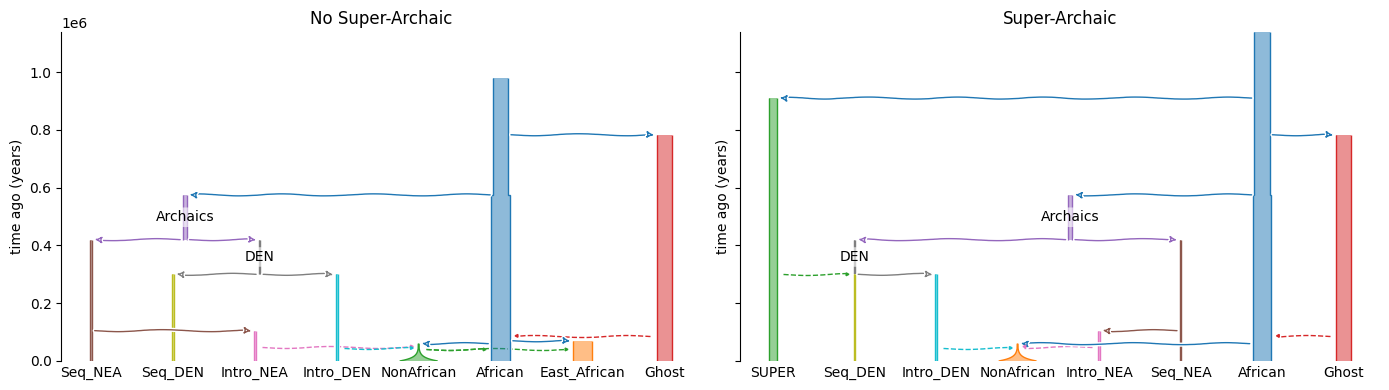

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(14,4), sharey='row')
models = ['Demography1_lwk_ghost', 'Demography1_super']
graph=demes.load("data/template_models/"+str(models[0])+".yaml")
demesdraw.tubes(graph, ax=ax[0], title='No Super-Archaic')
graph=demes.load("data/template_models/"+str(models[1])+".yaml")
demesdraw.tubes(graph, ax=ax[1], title='Super-Archaic')
fig.tight_layout()
plt.savefig('images/figS8_1.pdf', bbox_inches='tight')

# OCN trees

In [7]:
model = demes.load(f"data/template_models/Demography1_ooa_ocn.yaml")
demo = msprime.Demography.from_demes(model)
pop_dict = {i.name: i.id for i in demo.populations}
n = 12
ts = msprime.sim_ancestry(
    samples = [
        msprime.SampleSet(n, population=pop_dict["NonAfrican"]),
        msprime.SampleSet(n, population=pop_dict["African"]),
        # msprime.SampleSet(1, population=pop_dict["Seq_NEA"], time=1600),
        # msprime.SampleSet(1, population=pop_dict["Seq_DEN"], time=1500),
    ],
    sequence_length=50e6,
    recombination_rate=1e-8,
    random_seed=1,
    demography=demo,
    record_migrations = True,
)
ts2 = msprime.sim_ancestry(
    samples = [
        msprime.SampleSet(n, population=pop_dict["NonAfrican"]),
        msprime.SampleSet(n, population=pop_dict["African"]),
        # msprime.SampleSet(1, population=pop_dict["Seq_NEA"], time=1600),
        # msprime.SampleSet(1, population=pop_dict["Seq_DEN"], time=1500),
    ],
    sequence_length=50e6,
    recombination_rate=1e-8,
    random_seed=1,
    demography=demo,
)

In [8]:
trs = {}
for mr in ts.migrations():
    if mr.source == pop_dict["NonAfrican"] and mr.dest == pop_dict["Intro_NEA"]:
        for tree in ts.trees(leaf_lists=True):
            if mr.left > tree.interval.right:
                continue
            if mr.right <= tree.interval.left:
                break
            if not int((tree.interval.left + tree.interval.right) / 2) in trs:
                trs[int((tree.interval.left + tree.interval.right) / 2)] = [[], []]
            trs[int((tree.interval.left + tree.interval.right) / 2)][0].append(mr.node)
            u = tree.parent(mr.node)
            while u != tskit.NULL and tree.time(u) < 15000:
                trs[int((tree.interval.left + tree.interval.right) / 2)][0].append(u)
                u = tree.parent(u)
    if mr.source == pop_dict["NonAfrican"] and mr.dest == pop_dict["Intro_DEN"]:
        for tree in ts.trees(leaf_lists=True):
            if mr.left > tree.interval.right:
                continue
            if mr.right <= tree.interval.left:
                break
            if not int((tree.interval.left + tree.interval.right) / 2) in trs:
                trs[int((tree.interval.left + tree.interval.right) / 2)] = [[], []]
            trs[int((tree.interval.left + tree.interval.right) / 2)][1].append(mr.node)
            u = tree.parent(mr.node)
            while u != tskit.NULL and tree.time(u) < 15000:
                trs[int((tree.interval.left + tree.interval.right) / 2)][1].append(u)
                u = tree.parent(u)
            

In [9]:
trimed_trs = {}
for key, value in trs.items():
    if len(value[0]) > 0 and len(value[1]) > 0:
        s1 = set(value[0])
        s2 = set(value[1])
        if (s1 & s2):
            trimed_trs[key] = [value[0], value[1], list(s1 & s2)]

In [10]:
trimed_trs

{38769576: [[10237], [12, 8821, 8881, 10009, 10237, 15], [10237]],
 38838430: [[10237], [3212, 20, 6283, 9469, 10237], [10237]],
 27354656: [[9299, 45428], [9032, 45428], [45428]],
 27354794: [[9299, 45428], [9032, 45428], [45428]],
 27355592: [[9299, 45428], [9032, 45428], [45428]],
 27356488: [[9299, 45428], [9032, 45428], [45428]],
 27356710: [[9299, 45428], [9032, 45428], [45428]],
 27356915: [[9299, 45428], [9032, 45428], [45428]],
 27357072: [[9299, 45428], [9032, 45428], [45428]],
 27357112: [[9299, 45428], [9032, 45428], [45428]],
 27357267: [[9299, 45428], [9032, 45428], [45428]],
 27357423: [[9299, 45428], [9032, 45428], [45428]],
 27357465: [[9299, 45428], [9032, 45428], [45428]],
 27357970: [[9299, 45428], [9032, 45428], [45428]],
 27358498: [[9299, 45428], [9032, 45428], [45428]],
 27358925: [[9299, 45428], [9032, 45428], [45428]],
 27359429: [[9299, 45428], [9032, 45428], [45428]],
 27359539: [[9299, 45428], [9032, 45428], [45428]],
 27359649: [[9299, 45428], [9032, 45428

In [60]:
trs

{43792046: [[],
  [19, 6391, 37421, 7396, 18972, 6107, 10317, 18972, 8428, 10317, 18972]],
 43792462: [[],
  [19,
   14261,
   18972,
   7396,
   14261,
   18972,
   6107,
   10317,
   18972,
   8428,
   10317,
   18972]],
 43792561: [[],
  [19,
   14261,
   18972,
   7396,
   14261,
   18972,
   6107,
   10317,
   18972,
   8428,
   10317,
   18972]],
 43792846: [[],
  [19,
   14261,
   18972,
   7396,
   14261,
   18972,
   6107,
   10317,
   18972,
   8428,
   10317,
   18972]],
 43793193: [[],
  [19,
   14261,
   18972,
   7396,
   14261,
   18972,
   6107,
   10317,
   18972,
   8428,
   10317,
   18972]],
 43793404: [[],
  [19,
   14261,
   18972,
   7396,
   14261,
   18972,
   6107,
   10317,
   18972,
   8428,
   10317,
   18972]],
 43793556: [[],
  [19,
   14261,
   18972,
   7396,
   14261,
   18972,
   6107,
   10317,
   18972,
   8428,
   10317,
   18972]],
 43794223: [[],
  [19,
   14261,
   18972,
   7396,
   14261,
   18972,
   6107,
   10317,
   18972,
   8428,
   1031

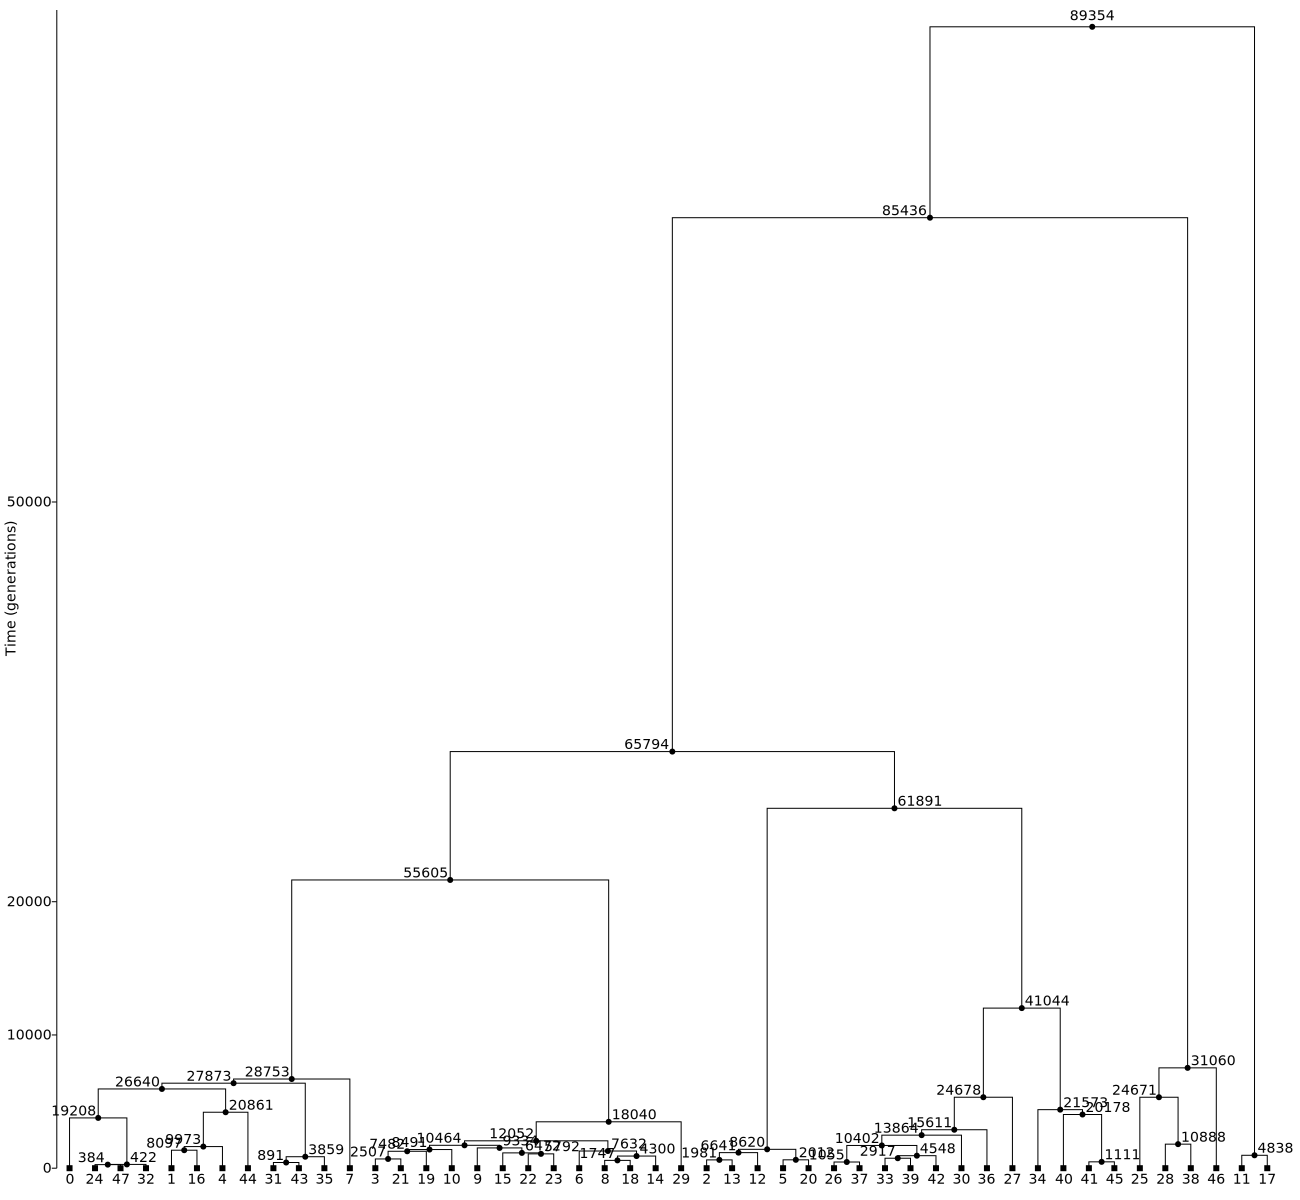

In [62]:
tree = ts.at(40593531)
LBS = {u: "" for u in tree.nodes()}
LBS[9299] = "NEA_INTRO"
LBS[9032] = "DEN_INTRO"
# display.SVG(tree.draw(node_labels=LBS, width=1300, height=1200))
tree.draw_svg("images/figS7_tree.png", size = (1300, 1200), y_axis=True, y_ticks=[0, 10000, 20000, 50000, 100000])

In [7]:
sl = []
for s in tree.samples(129331):
    sl.append(s)
len(sl)

17

In [58]:
tree.time(45428)

14494.403180290563

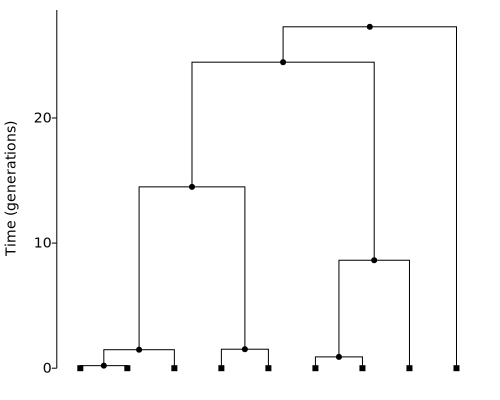

In [ ]:
lst = [0, 15, 19, 4, 16, 28, 32, 47, 1]
tss = ts2.simplify(samples=lst)
tree = tss.at(27356710)
LBS = {u: "" for u in tree.nodes()}
# LBS[1199] = "NEA_INTRO"
# LBS[1284] = "DEN_INTRO"
tree.draw_svg("images/figS7_tree.png", size = (500, 400), y_axis=True, y_ticks={0:0, 10000:10, 20000:20}, node_labels=LBS)
# display.SVG(tree.draw("images/figS7_tree.svg", format = 'svg', width=500, height=400, node_colours={1199: "orange", 0:"orange", 1:"orange", 2:"orange", 16:"orange", 1284: "blue", 3: "blue", 4: "blue"}, 
        # edge_colours={0:"orange", 1:"orange", 2:"orange", 16:"orange", 3: "blue", 4: "blue"}, node_labels=LBS))

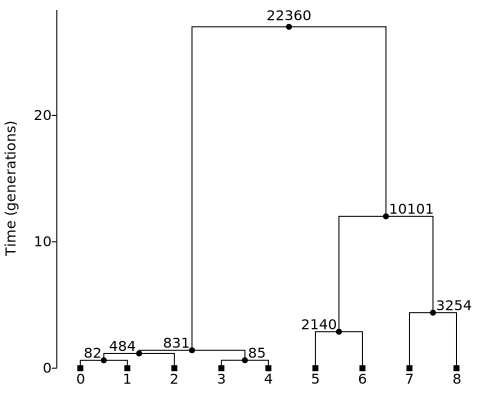

In [71]:
lst = [2, 13, 12, 5, 20, 36, 37, 34, 40]
tss = ts2.simplify(samples=lst)
tree = tss.at(40593531)
LBS = {u: "" for u in tree.nodes()}
tree.draw_svg("images/figS7_tree2.png", size = (500, 400), y_axis=True, y_ticks={0:0, 10000:10, 20000:20, 50000:50, 100000: 100, 200000: 200})#, node_labels=LBS)
# display.SVG(tree.draw("images/figS7_tree2.svg", format = 'svg', width=500, height=400, node_colours={0: "orange",1: "orange", 3: "orange", 4: "orange", 2: "orange", 82: "orange", 484: "orange", 85: "orange", 831: "orange"},
        # edge_colours = {0: "orange",1: "orange", 3: "orange", 4: "orange", 2: "orange", 82: "orange", 484: "orange", 85: "orange"}, node_labels=LBS))

In [ ]:
model = demes.load(f"data/template_models/Demography1_nosup.yaml")
demo = msprime.Demography.from_demes(model)
pop_dict = {i.name: i.id for i in demo.populations}
n = 100
ts = msprime.sim_ancestry(
    samples = [
        msprime.SampleSet(n, population=pop_dict["NonAfrican"]),
        msprime.SampleSet(n, population=pop_dict["African"]),
        # msprime.SampleSet(1, population=pop_dict["Seq_NEA"], time=1600),
        # msprime.SampleSet(1, population=pop_dict["Seq_DEN"], time=1500),
    ],
    sequence_length=50e6,
    recombination_rate=1e-8,
    random_seed=1,
    demography=demo,
    record_migrations = True,
)
lvs = range(10)
trs = {}
cts = []
for mr in ts.migrations():
    if mr.source == pop_dict["NonAfrican"] and mr.dest == pop_dict["Intro_NEA"]:
        for tree in ts.trees(leaf_lists=True):
            if mr.left > tree.interval.right:
                continue
            if mr.right <= tree.interval.left:
                break
            local = False
            inlvs = []
            for leaf in tree.leaves(mr.node):
                if leaf in lvs:
                    local = True
                    inlvs.append(leaf)
                if leaf == 0:
                    cts.append(int((tree.interval.left + tree.interval.right) / 2))
            if not local:
                continue
            if not int((tree.interval.left + tree.interval.right) / 2) in trs:
                trs[int((tree.interval.left + tree.interval.right) / 2)] = [[], [], [], []]
            trs[int((tree.interval.left + tree.interval.right) / 2)][0].append(mr.node)
            trs[int((tree.interval.left + tree.interval.right) / 2)][2].append(len(inlvs))
            lst_time = tree.time(u)
            u = tree.parent(mr.node)
            while u != tskit.NULL and tree.time(u) < 19275:
                trs[int((tree.interval.left + tree.interval.right) / 2)][0].append(u)
                lst_time = tree.time(u)
                u = tree.parent(u)
            trs[int((tree.interval.left + tree.interval.right) / 2)][3].append(tree.time(u) - lst_time)
    if mr.source == pop_dict["NonAfrican"] and mr.dest == pop_dict["Intro_DEN"]:
        for tree in ts.trees(leaf_lists=True):
            if mr.left > tree.interval.right:
                continue
            if mr.right <= tree.interval.left:
                break
            local = False
            inlvs = []
            for leaf in tree.leaves(mr.node):
                if leaf in lvs:
                    local = True
                    inlvs.append(leaf)
                if leaf == 0:
                    cts.append(int((tree.interval.left + tree.interval.right) / 2))
            if not local:
                continue
            if not int((tree.interval.left + tree.interval.right) / 2) in trs:
                trs[int((tree.interval.left + tree.interval.right) / 2)] = [[], [], [], []]
            trs[int((tree.interval.left + tree.interval.right) / 2)][1].append(mr.node)
            trs[int((tree.interval.left + tree.interval.right) / 2)][2].append(len(inlvs))
            lst_time = tree.time(u)
            u = tree.parent(mr.node)
            while u != tskit.NULL and tree.time(u) < 19275:
                trs[int((tree.interval.left + tree.interval.right) / 2)][1].append(u)
                lst_time = tree.time(u)
                u = tree.parent(u)
            trs[int((tree.interval.left + tree.interval.right) / 2)][3].append(tree.time(u) - lst_time)

In [22]:
trimed_trs = {}
arc_trs = {}
for key, value in trs.items():
    if len(value[0]) > 0 and len(value[1]) > 0:
        s1 = set(value[0])
        s2 = set(value[1])
        if (s1 & s2):
            trimed_trs[key] = [value[0], value[1], list(s1 & s2), value[2], value[3]]
    else:
        arc_trs[key] = [value[0], value[1], value[2], value[3]]

In [ ]:
hmm = GhostProductHmm()
ncoal, t1s, t2s, treespan, nleaves = hmm.prepare_data_tmrca(ts = ts2, ind = 0, t_archaic=15000)
arc = []
for key, value in arc_trs.items():
    for j in range(len(value[2])):
        arc = arc + value[2][j] * [value[3][j]]
shared = []
for key, value in trimed_trs.items():
    for j in range(len(value[3])):
        shared = shared + value[3][j] * [value[4][j]]
pos = treespan[:, 1] - treespan[:, 0]
pos = pos.astype(int)

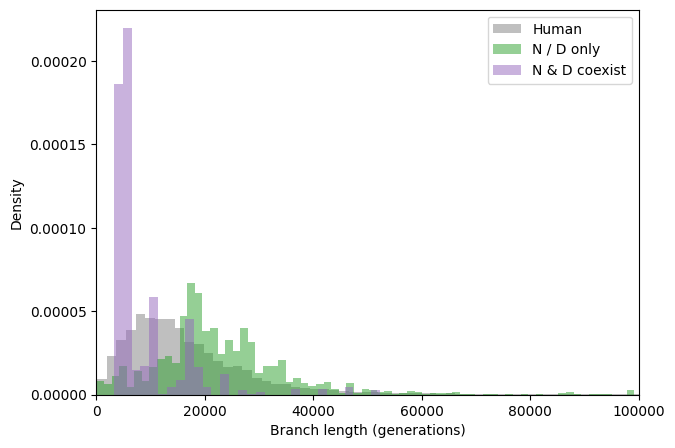

In [62]:
arc = np.array(arc)
shared = np.array(shared)
fig, ax = plt.subplots(1, 1, figsize=(7,5))#, sharey='row', sharex='row')
ax.hist((t2s - t1s)[~np.isin(pos, np.array(cts))], bins=200, density=True, alpha=0.5, label='Human', color='gray');
ax.hist(arc[arc > 0], bins=200, density=True, alpha=0.5, label='N / D only', color = 'C2');
# ax[1].hist((t2s - t1s)[~np.isin(pos, np.array(cts))], bins=100, density=True, alpha=0.5, label='Human');
ax.hist(shared[shared > 0], bins=100, density=True, alpha=0.5, label='N & D coexist', color = 'C4');
ax.set_xlabel('Branch length (generations)')
ax.set_ylabel('Density')
ax.legend()
ax.set_xlim(0, 100000)
plt.savefig('images/figS8_6.pdf', bbox_inches='tight')

# summarize

In [ ]:
%%bash
for i in {0..39}
do
    python summarize.py --file results/realdata/test_simulation/singer/singer_t15000_ind${i}.chr1.xss.npz --out results/realdata/test_simulation/singer/singer_t15000_ind${i}
done
for i in {1..10}
do
    paste <(bcftools view -M 2 -m 2 ../msprime/n100_seed${i}.vcf -Ov | bcftools query -f "%CHROM\t%POS\t%REF\t%ALT\n") <(cut -f5 ../ibdmix/n100_seed${i}_altai.gt|tail -n +2) <(cut -f5 ../ibdmix/n100_seed${i}_den.gt|tail -n +2) > n100_seed${i}.txt
    echo -e "chrom\tpos\tref\talt\taltai\tdenisova" | cat - n100_seed${i}.txt > temp && mv temp n100_seed${i}.txt
done
sed 's/^/chr/' chr1.txt > output.txt
from workflow.scripts.utils import SNPINFO
for i in range(1, 11):
    hgdp_bcf = f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/msprime/n100_seed{i}.vcf"
    gbr_label = f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/snpinfo/wafr.sample"
    afr_label = f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/snpinfo/eafr.sample"
    gbrafr_label = f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/snpinfo/afr.sample"
    outpref = f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/snpinfo/n100_seed{i}_afr.af"
    snpinfo = f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/snpinfo/n100_seed{i}"
    SNPINFO().append_AFR_info(snpinfo, hgdp_bcf, gbr_label, "AltAF_EUR", outpref)
    SNPINFO().append_AFR_info(outpref, hgdp_bcf, afr_label, "AltAF_AFR", outpref)
    SNPINFO().append_AFR_info(outpref, hgdp_bcf, gbrafr_label, "AltAF_EURAFR", outpref)
    snpinfo = f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/snpinfo/n100_seed{i}_afr.af"
    mutage_pref = f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/singer_afr/n100_seed{i}_mutage_"
    mutage_range = range(250, 300)
    outpref = f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/snpinfo/n100_seed{i}_afr.af.mutage"
    SNPINFO().append_mutage_info(snpinfo, mutage_pref, mutage_range, outpref)

In [ ]:
for s in range(1,11):
    try:
        df = pd.read_csv(f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/msprime/n100_seed{s}.NEA.indiv.bed", sep="\t", header=None)
        df.columns = ["chromosome", "start", "end", "ID"]
        df["archaic"] = "Neanderthal"
    except:
        print(f"n100_seed{s}.NEA.indiv.bed not found or empty, skip")
        df = pd.DataFrame(columns=["chromosome", "start", "end", "ID", "archaic"])
    try:
        df1 = pd.read_csv(f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/msprime/n100_seed{s}.DEN.indiv.bed", sep="\t", header=None)
        df1.columns = ["chromosome", "start", "end", "ID"]
        df1["archaic"] = "Denisova"
        df = pd.concat([df, df1], ignore_index=True)
    except:
        print(f"n100_seed{s}.DEN.indiv.bed not found or empty, skip")
    try:
        df1 = pd.read_csv(f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/msprime/n100_seed{s}.Ghost.indiv.bed", sep="\t", header=None)
        df1.columns = ["chromosome", "start", "end", "ID"]
        df1["archaic"] = "Ghost"
        df = pd.concat([df, df1], ignore_index=True)
    except:
        print(f"n100_seed{s}.Ghost.indiv.bed not found or empty, skip")
    # try:
    #     df1 = pd.read_csv(f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/msprime/n100_seed{s}.SUPER.indiv.bed", sep="\t", header=None)
    #     df1.columns = ["chromosome", "start", "end", "ID"]
    #     df1["archaic"] = "SUPER"
    #     df = pd.concat([df, df1], ignore_index=True)
    # except:
    #     print(f"n100_seed{s}.SUPER.indiv.bed not found or empty, skip")
    df["start"] = df["start"]*1e6
    df["start"] = df["start"].astype(int)
    df["end"] = df["end"]*1e6
    df["end"] = df["end"].astype(int)
    df.to_csv(f"/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/test_simulation/lwk_ghost_model/msprime/n100_seed{s}.arc.indiv.tsv", sep="\t", index=False, header=True)

NameError: name 'pd' is not defined

In [ ]:
for i in range(1,11):
    df = pd.read_csv(f"n100_seed{i}_altai.ibdmix", sep="\t")
    df["archaic"] = "Neanderthal"
    df1 = pd.read_csv(f"n100_seed{i}_den.ibdmix", sep="\t")
    df1["archaic"] = "Denisova"
    df = pd.concat([df, df1], ignore_index=True)
    df.to_csv(f"n100_seed{i}.arc.ibdmix", sep="\t", index=False, header=True)

In [ ]:
hmmixfile = "results/realdata/test_simulation/msprime/n100_seed5.arc.indiv.tsv"
summaryfile = "results/realdata/test_simulation/singer/singer_t15000_ind0.summary.txt"
outpref = "results/realdata/test_simulation/singer/singer_t15000_ind0.truth"
append_hmmix_info(hmmixfile, summaryfile, outpref, inference = "truth", individualID = 0)
summaryfile = "results/realdata/test_simulation/singer/singer_t15000_ind0.truth.txt"
hmmixfile = "results/realdata/test_simulation/hmmix/n100_seed5.tsk_0.hap1.txt"
outpref = "results/realdata/test_simulation/singer/singer_t15000_ind0.truth.hmmix"
append_hmmix_info(hmmixfile, summaryfile, outpref, inference = "hmmix", individualID = 0)
summaryfile = "results/realdata/test_simulation/singer/singer_t15000_ind0.truth.hmmix.txt"
hmmixfile = "results/realdata/test_simulation/ibdmix/n100_seed5.arc.ibdmix"
outpref = "results/realdata/test_simulation/singer/singer_t15000_ind0.truth.hmmix.ibdmix"
append_hmmix_info(hmmixfile, summaryfile, outpref, inference = "ibdmix", individualID = "tsk_0")

In [9]:
dff = pd.read_csv("results/realdata/test_simulation/lwk_ghost_model/singer_afr/treeID.txt", sep='\t')
# for s in range(1, 11):
#     iidx = 0
#     while not os.path.exists(f'results/realdata/test_simulation/nosup_model/arghmm/n100_seed{s}_t15000_ind{iidx}.count_merge.txt'):
#         print(f"File results/realdata/test_simulation/nosup_model/arghmm/n100_seed{s}_t15000_ind{iidx}.count_merge.txt does not exist.")
#         iidx += 1
#     df = pd.read_csv(f'results/realdata/test_simulation/nosup_model/arghmm/n100_seed{s}_t15000_ind{iidx}.count_merge.txt', sep = '\t')
#     df["samplename"] = dff[dff["ID"] == iidx]["Name"].values[0]
#     df["ID"] = iidx
#     df["chromosome"] = s
#     for i in range(int(iidx + 1), 100):
#         if not os.path.exists(f'results/realdata/test_simulation/nosup_model/arghmm/n100_seed{s}_t15000_ind{i}.count_merge.txt'):
#             print(f"File results/realdata/test_simulation/nosup_model/arghmm/n100_seed{s}_t15000_ind{i}.count_merge.txt does not exist.")
#             continue
#         df1 = pd.read_csv(f'results/realdata/test_simulation/nosup_model/arghmm/n100_seed{s}_t15000_ind{i}.count_merge.txt', sep = '\t')
#         df1["samplename"] = dff[dff["ID"] == i]["Name"].values[0]
#         df1["ID"] = i
#         df1["chromosome"] = s
#         df = pd.concat([df, df1])
#     if s == 1:
#         dft = df
#     else:
#         dft = pd.concat([dft, df])
# dft.to_csv("results/realdata/test_simulation/super_model/arghmm/singerave_t15000_gbr.count_merge.txt", index = False, sep = '\t')
for s in range(1, 11):
    iidx = 200
    while not os.path.exists(f'results/realdata/test_simulation/lwk_ghost_model/singer_afr/n100_seed{s}_t15000_ind{iidx}.count_merge.txt'):
        print(f"File results/realdata/test_simulation/lwk_ghost_model/singer_afr/n100_seed{s}_t15000_ind{iidx}.count_merge.txt does not exist.")
        iidx += 1
    df = pd.read_csv(f'results/realdata/test_simulation/lwk_ghost_model/singer_afr/n100_seed{s}_t15000_ind{iidx}.count_merge.txt', sep = '\t')
    df["samplename"] = dff[dff["ID"] == iidx]["Name"].values[0]
    df["ID"] = iidx
    df["chromosome"] = s
    for i in range(int(iidx + 1), 300):
        if not os.path.exists(f'results/realdata/test_simulation/lwk_ghost_model/singer_afr/n100_seed{s}_t15000_ind{i}.count_merge.txt'):
            print(f"File results/realdata/test_simulation/lwk_ghost_model/singer_afr/n100_seed{s}_t15000_ind{i}.count_merge.txt does not exist.")
            continue
        df1 = pd.read_csv(f'results/realdata/test_simulation/lwk_ghost_model/singer_afr/n100_seed{s}_t15000_ind{i}.count_merge.txt', sep = '\t')
        df1["samplename"] = dff[dff["ID"] == i]["Name"].values[0]
        df1["ID"] = i
        df1["chromosome"] = s
        df = pd.concat([df, df1])
    if s == 1:
        dft = df
    else:
        dft = pd.concat([dft, df])
dft.to_csv("results/realdata/test_simulation/lwk_ghost_model/singer_afr/singerave_t15000_yri.count_merge.txt", index = False, sep = '\t')

In [13]:
dff = pd.read_csv("results/realdata/test_simulation/super_model/arghmm/treeID.txt", sep='\t')
for s in range(1, 11):
    iidx = 0
    while not os.path.exists(f'results/realdata/test_simulation/super_model/arghmm/n100_seed{s}_t31500_ind{iidx}.count_merge.txt'):
        print(f"File results/realdata/test_simulation/super_model/arghmm/n100_seed{s}_t31500_ind{iidx}.count_merge.txt does not exist.")
        iidx += 1
    df = pd.read_csv(f'results/realdata/test_simulation/super_model/arghmm/n100_seed{s}_t31500_ind{iidx}.count_merge.txt', sep = '\t')
    df["samplename"] = dff[dff["ID"] == iidx]["Name"].values[0]
    df["ID"] = iidx
    for i in range(int(iidx + 1), 100):
        if not os.path.exists(f'results/realdata/test_simulation/super_model/arghmm/n100_seed{s}_t31500_ind{i}.count_merge.txt'):
            print(f"File results/realdata/test_simulation/super_model/arghmm/n100_seed{s}_t31500_ind{i}.count_merge.txt does not exist.")
            continue
        df1 = pd.read_csv(f'results/realdata/test_simulation/super_model/arghmm/n100_seed{s}_t31500_ind{i}.count_merge.txt', sep = '\t')
        df1["samplename"] = dff[dff["ID"] == i]["Name"].values[0]
        df1["ID"] = i
        df1["chromosome"] = s
        df = pd.concat([df, df1])
    if s == 1:
        dft = df
    else:
        dft = pd.concat([dft, df])
dft.to_csv("results/realdata/test_simulation/super_model/arghmm/singerave_t31500_t15000_den.count_merge.txt", index = False, sep = '\t')

# Comparison with other methods

In [10]:
prec_singer = []
rec_singer = []
tot_hmm_singer = []
tot_arc_singer = []
tot_tp = []
data = pd.read_csv("results/realdata/test_simulation/lwk_ghost_model/singer_afr/singerave_t15000_yri.count_merge.txt", sep = '\t')
data = data[(data["nderived"] > 30) & (data[["ND00", "ND10", "ND01", "ND11"]].sum(axis = 1) > 10)]
# data.loc[((data['nd00_prop'] <= 0.8) | (data['nYRI'] <= 0.1)) & (data['nd10_b'] > data['nd01_b']), 'assign_label'] = 'NEA'
# data.loc[((data['nd00_prop'] <= 0.8) | (data['nYRI'] <= 0.1)) & (data['nd10_b'] < data['nd01_b']), 'assign_label'] = 'DEN'
# data.loc[(data['nd00_prop'] > 0.8) & (data['nYRI'] > 0.1), 'assign_label'] = 'Ghost'
for s in range(1, 11):
    subdata = data[(data["chromosome"] == s) & (data["assign_label"] == "Ghost")]
    # subdata = data[(data["chromosome"] == s) & (data["assign_label"].isin(["NEA", "DEN", "Ghost"]))]
    # ibdmix = pd.read_csv(f"results/realdata/test_simulation/super_model/ibdmix/n100_seed{s}.arc.ibdmix", sep="\t")
    truth = Performance_utils().read_truth_bed(f"results/realdata/test_simulation/lwk_ghost_model/msprime/n100_seed{s}.arc.indiv.tsv", 400)
    for ind in range(200, 300):
        inferred = list(subdata[subdata["ID"] == ind][['start', 'end']].itertuples(index=False, name=None))
        # hmmix = pd.read_csv(f"results/realdata/test_simulation/super_model/hmmix/n100_seed{s}.tsk_{int(ind / 2)}.hap{int(ind % 2) + 1}.txt", sep="\t")
        # hmmix = hmmix[(hmmix['state']=='Archaic') & (hmmix['mean_prob'] >= 0.8) & (hmmix['end'] - hmmix['start'] + 1000 >= 5e4)]
        # hmmix = hmmix[(hmmix['tsk_200'] > 0) | (hmmix['tsk_201'] > 0)]
        # hmmix = hmmix[hmmix['tsk_200'] < hmmix['tsk_201']]
        # hmmix['end'] = hmmix['end'] + 1e3
        # inferred = list(hmmix[['start', 'end']].itertuples(index=False, name=None))
        # subibdmix = ibdmix[(ibdmix['slod']>=4) & (ibdmix['end'] - ibdmix['start'] >= 5e4) & (ibdmix['ID'] == f"tsk_{int(ind / 2)}")]
        # subibdmix = subibdmix[subibdmix['archaic'] == "Neanderthal"]
        # inferred = list(subibdmix[['start', 'end']].itertuples(index=False, name=None))
        # ibdmix = [(hmmix.iloc[i, 0], hmmix.iloc[i, 1] + 1e3) for i in range(len(hmmix))] + [(ibdmix.iloc[i, 0], ibdmix.iloc[i, 1]) for i in range(len(ibdmix))]
        pre, rec, _, _, _, tot_hmm = Performance_utils().calculate_performance(inferred, truth[ind])
        # if ind % 2 == 0:
        #     if len(truth[ind]) > 0 and len(truth[ind + 1]) > 0:
        #         tru = np.vstack((truth[ind], truth[ind + 1]))
        #     elif len(truth[ind]) > 0:
        #         tru = truth[ind]
        #     elif len(truth[ind + 1]) > 0:
        #         tru = truth[ind + 1]
        #     else:
        #         tru = np.array([])
        # else:
        #     if len(truth[ind]) > 0 and len(truth[ind - 1]) > 0:
        #         tru = np.vstack((truth[ind], truth[ind - 1]))
        #     elif len(truth[ind]) > 0:
        #         tru = truth[ind]
        #     elif len(truth[ind - 1]) > 0:
        #         tru = truth[ind - 1]
        #     else:
        #         tru = np.array([])
        # pre, rec, tp, _, tot_arc, tot_hmm = Performance_utils().calculate_performance(inferred, tru)
        # pre, rec, _, _, _, tot_hmm = Performance_utils().calculate_performance(inferred, ibdmix)
        # pre, rec, _, _, _, tot_hmm = Performance_utils().calculate_performance([(hmmix.iloc[i, 0], hmmix.iloc[i, 1] + 1e3) for i in range(len(hmmix))], [(ibdmix.iloc[i, 0], ibdmix.iloc[i, 1]) for i in range(len(ibdmix))])
        prec_singer.append(pre)
        rec_singer.append(rec)
        tot_hmm_singer.append(np.sum([x[1] - x[0] for x in inferred]))
        # tot_arc_singer.append(tot_arc)
        # tot_tp.append(np.sum(tp))
np.nanmean(prec_singer), np.nanmean(rec_singer), np.nanmean(tot_hmm_singer) / 50e6#, np.nanmean(tot_arc_singer), np.nanmean(tot_tp) / 50e6

(0.9239542575542876, 0.09635578645884342, 0.0093083)

In [12]:
outda = {"chromosome": [], "precision": [], "recall": [], "ID": [], "total_length": [], "run":[]}
da = pd.read_csv("results/realdata/test_simulation/lwk_ghost_model/singer_wafr/singerave_t15000_yri.count_merge.txt", sep = '\t')
da = da[(da["nderived"] > 30) & (da[["ND00", "ND10", "ND01", "ND11"]].sum(axis = 1) > 10)]
for s in range(1, 11):
    subda = da[(da["chromosome"] == s) & (da["assign_label"] == "Ghost")]
    truth = Performance_utils().read_truth_bed(f"results/realdata/test_simulation/lwk_ghost_model/msprime/n100_seed{s}.arc.indiv.tsv", 400)
    for ind in range(200, 300):
        inferred = list(subda[subda["ID"] == ind][['start', 'end']].itertuples(index=False, name=None))
        pre, rec, _, _, _, tot_hmm = Performance_utils().calculate_performance(inferred, truth[ind])
        outda["precision"].append(pre)
        outda["recall"].append(rec)
        outda["chromosome"].append(s)
        outda["ID"].append(ind)
        outda["total_length"].append(np.sum([x[1] - x[0] for x in inferred]))
        outda["run"].append("wafr")
da = pd.read_csv("results/realdata/test_simulation/lwk_ghost_model/singer_afr/singerave_t15000_yri.count_merge.txt", sep = '\t')
da = da[(da["nderived"] > 30) & (da[["ND00", "ND10", "ND01", "ND11"]].sum(axis = 1) > 10)]
for s in range(1, 11):
    subda = da[(da["chromosome"] == s) & (da["assign_label"] == "Ghost")]
    truth = Performance_utils().read_truth_bed(f"results/realdata/test_simulation/lwk_ghost_model/msprime/n100_seed{s}.arc.indiv.tsv", 400)
    for ind in range(200, 300):
        inferred = list(subda[subda["ID"] == ind][['start', 'end']].itertuples(index=False, name=None))
        pre, rec, _, _, _, tot_hmm = Performance_utils().calculate_performance(inferred, truth[ind])
        outda["precision"].append(pre)
        outda["recall"].append(rec)
        outda["chromosome"].append(s)
        outda["ID"].append(ind)
        outda["total_length"].append(np.sum([x[1] - x[0] for x in inferred]))
        outda["run"].append("afr")
da = pd.read_csv("results/realdata/test_simulation/lwk_ghost_model/singer_eur/singerave_t15000_yri.count_merge.txt", sep = '\t')
da = da[(da["nderived"] > 30) & (da[["ND00", "ND10", "ND01", "ND11"]].sum(axis = 1) > 10)]
for s in range(1, 11):
    subda = da[(da["chromosome"] == s) & (da["assign_label"] == "Ghost")]
    truth = Performance_utils().read_truth_bed(f"results/realdata/test_simulation/lwk_ghost_model/msprime/n100_seed{s}.arc.indiv.tsv", 400)
    for ind in range(200, 300):
        inferred = list(subda[subda["ID"] == ind][['start', 'end']].itertuples(index=False, name=None))
        pre, rec, _, _, _, tot_hmm = Performance_utils().calculate_performance(inferred, truth[ind])
        outda["precision"].append(pre)
        outda["recall"].append(rec)
        outda["chromosome"].append(s)
        outda["ID"].append(ind)
        outda["total_length"].append(np.sum([x[1] - x[0] for x in inferred]))
        outda["run"].append("eur")
outdf = pd.DataFrame(outda)


/global/scratch/users/zhangyulin9806/tmp/ipykernel_158246/3610514156.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=totl, x="run", y="total_length", palette={"afr": "C4", "wafr": "C2", "eur": "C0"}, order=["afr", "eur", "wafr"])


Text(0.5, 1.0, 'Ghost proportion in YRI')

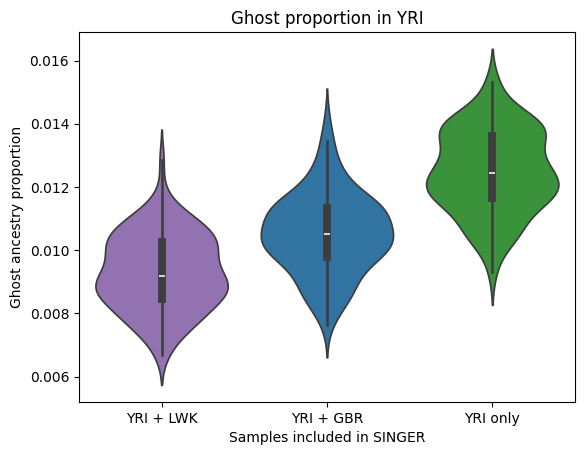

In [22]:
totl = outdf.groupby(["run", "ID"])["total_length"].sum().reset_index()
totl["total_length"] = totl["total_length"] / 500e6
sns.violinplot(data=totl, x="run", y="total_length", palette={"afr": "C4", "wafr": "C2", "eur": "C0"}, order=["afr", "eur", "wafr"])
plt.xlabel("Samples included in SINGER")
plt.ylabel("Ghost ancestry proportion")
plt.xticks([0, 1, 2], ["YRI + LWK", "YRI + GBR", "YRI only"])
plt.title("Ghost proportion in YRI")

Text(0.5, 1.0, 'Precision of Ghost inference in YRI')

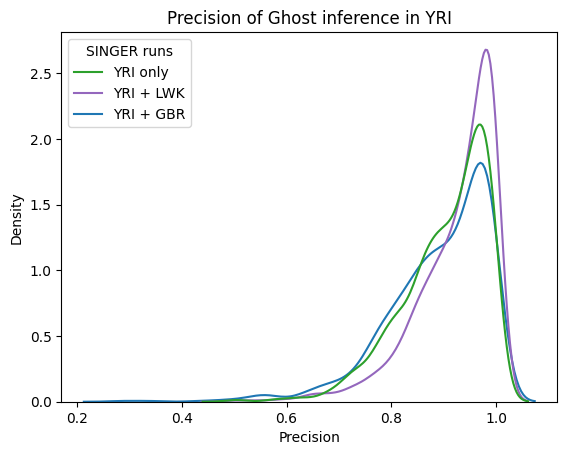

In [31]:
outdf['SINGER runs'] = outdf['run'].map({'afr': 'YRI + LWK', 'wafr': 'YRI only', 'eur': 'YRI + GBR'})
sns.kdeplot(data=outdf, x="precision", hue = "SINGER runs", palette={"YRI + LWK": "C4", "YRI only": "C2", "YRI + GBR": "C0"})
plt.xlabel("Precision")
plt.ylabel("Density")
# plt.xticks([0, 1, 2], ["YRI + LWK", "YRI + GBR", "YRI only"])
plt.title("Precision of Ghost inference in YRI")

Text(0.5, 1.0, 'Recall of Ghost inference in YRI')

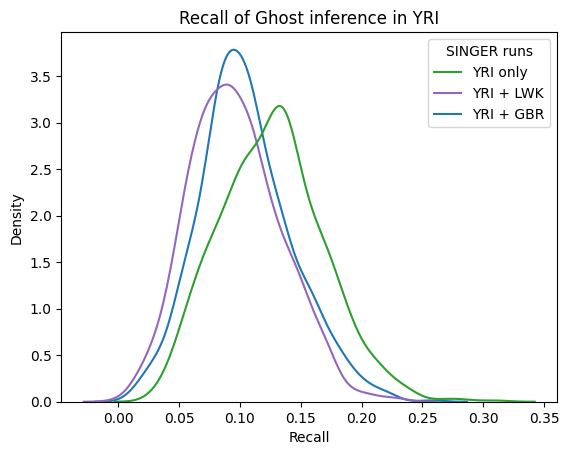

In [32]:
sns.kdeplot(data=outdf, x="recall", hue = "SINGER runs", palette={"YRI + LWK": "C4", "YRI only": "C2", "YRI + GBR": "C0"})
plt.xlabel("Recall")
plt.ylabel("Density")
# plt.xticks([0, 1, 2], ["YRI + LWK", "YRI + GBR", "YRI only"])
plt.title("Recall of Ghost inference in YRI")

In [34]:
dff = pd.read_csv("results/realdata/test_simulation/lwk_ghost_model/singer_wafr/singerave_t15000_yri.count_merge.txt", sep="\t")
df = pd.read_csv("results/realdata/test_simulation/lwk_ghost_model/singer_afr/singerave_t15000_yri.count_merge.txt", sep='\t')
overlap_arr_trace = np.zeros((3, len(dff["samplename"].unique())))
overlap_arr_archie = np.zeros((3, len(dff["samplename"].unique())))
tot_arr_archie = np.zeros((3, len(dff["samplename"].unique())))
tot_arr_trace = np.zeros((3, len(dff["samplename"].unique())))
overlap_arr_trace_reg = np.zeros((3, len(dff["samplename"].unique())))
overlap_arr_archie_reg = np.zeros((3, len(dff["samplename"].unique())))
tot_arr_archie_reg = np.zeros((3, len(dff["samplename"].unique())))
tot_arr_trace_reg = np.zeros((3, len(dff["samplename"].unique())))
for idx, id in enumerate(dff["samplename"].unique()):
    sub = dff[(dff["samplename"]==id)]
    sub_nea = sub[(sub["assign_label"]=="NEA")]
    archie_bed = pybedtools.BedTool.from_dataframe(sub_nea[["chromosome", "start", "end"]])
    sub2 = df[(df["samplename"]==id)]
    sub2_nea = sub2[(sub2["assign_label"]=="NEA")]
    trace_bed = pybedtools.BedTool.from_dataframe(sub2_nea[["chromosome", "start", "end"]])
    intersect = trace_bed.intersect(archie_bed, u=True)
    overlap_arr_trace[0, idx] = len(intersect)
    intersect = trace_bed.intersect(archie_bed)
    overlap_arr_trace_reg[0, idx] = sum([iv.length for iv in intersect])
    intersect = archie_bed.intersect(trace_bed, u=True)
    overlap_arr_archie[0, idx] = len(intersect)
    intersect = archie_bed.intersect(trace_bed)
    overlap_arr_archie_reg[0, idx] = sum([iv.length for iv in intersect])
    tot_arr_archie[0, idx] = len(sub_nea)
    tot_arr_trace[0, idx] = len(sub2_nea)
    tot_arr_trace_reg[0, idx] = sum(sub2_nea["length(bp)"])
    tot_arr_archie_reg[0, idx] = sum(sub_nea["length(bp)"])
    sub_den = sub[(sub["assign_label"]=="DEN")]
    archie_bed = pybedtools.BedTool.from_dataframe(sub_den[["chromosome", "start", "end"]])
    sub2_den = sub2[(sub2["assign_label"]=="DEN")]
    trace_bed = pybedtools.BedTool.from_dataframe(sub2_den[["chromosome", "start", "end"]])
    intersect = trace_bed.intersect(archie_bed, u=True)
    overlap_arr_trace[1, idx] = len(intersect)
    intersect = trace_bed.intersect(archie_bed)
    overlap_arr_trace_reg[1, idx] = sum([iv.length for iv in intersect])
    intersect = archie_bed.intersect(trace_bed, u=True)
    overlap_arr_archie[1, idx] = len(intersect)
    intersect = archie_bed.intersect(trace_bed)
    overlap_arr_archie_reg[1, idx] = sum([iv.length for iv in intersect])
    tot_arr_archie[1, idx] = len(sub_den)
    tot_arr_trace[1, idx] = len(sub2_den)
    tot_arr_trace_reg[1, idx] = sum(sub2_den["length(bp)"])
    tot_arr_archie_reg[1, idx] = sum(sub_den["length(bp)"])
    sub_ghost = sub#[(sub["assign_label"]=="Ghost")]
    archie_bed = pybedtools.BedTool.from_dataframe(sub_ghost[["chromosome", "start", "end"]])
    print(np.sum([iv.length for iv in archie_bed]))
    sub2_ghost = sub2#[(sub2["assign_label"]=="Ghost")]
    trace_bed = pybedtools.BedTool.from_dataframe(sub2_ghost[["chromosome", "start", "end"]])
    print(np.sum([iv.length for iv in trace_bed]))
    intersect = trace_bed.intersect(archie_bed, u=True)
    overlap_arr_trace[2, idx] = len(intersect)
    intersect = trace_bed.intersect(archie_bed)
    overlap_arr_trace_reg[2, idx] = sum([iv.length for iv in intersect])
    intersect = archie_bed.intersect(trace_bed, u=True)
    overlap_arr_archie[2, idx] = len(intersect)
    intersect = archie_bed.intersect(trace_bed)
    overlap_arr_archie_reg[2, idx] = sum([iv.length for iv in intersect])
    tot_arr_archie[2, idx] = len(sub_ghost)
    tot_arr_trace[2, idx] = len(sub2_ghost)
    tot_arr_trace_reg[2, idx] = sum(sub2_ghost["length(bp)"])
    tot_arr_archie_reg[2, idx] = sum(sub_ghost["length(bp)"])

6993000
6051000
7517000
5076000
6751000
5260000
6961000
5270000
6887000
5256000
7619000
5941000
7818000
5596000
7731000
6684000
7509000
5084000
6779000
4892000
7319000
6802000
5609000
4484000
7781000
6135000
6726000
5901000
7349000
5189000
7183000
4384000
7461000
5395000
5014000
4003000
6686000
5898000
6562000
4723000
6078000
5698000
7419000
5883000
6002000
4548000
6594000
5629000
6179000
4294000
8252000
4843000
7003000
5978000
5829000
5149000
8073000
6003000
6285000
4918000
6992000
5210000
7315000
6257000
8144000
5303000
7946000
5507000
8018000
6850000
6791000
4930000
6238000
5691000
6255000
3713000
6500000
4748000
6859000
5765000
6483000
4435000
6600000
5646000
6661000
4630000
6306000
4950000
6846000
5144000
7424000
4533000
5732000
5503000
6970000
5526000
5903000
4793000
7073000
5704000
7258000
4830000
6084000
4316000
7600000
4804000
6911000
5410000
6102000
5281000
7442000
5382000
6341000
5159000
7772000
5917000
7401000
5851000
6314000
4653000
5775000
5311000
7420000
4785000
6380000


In [35]:
np.nanmean(overlap_arr_trace_reg / tot_arr_trace_reg, axis=1), np.nanpercentile(overlap_arr_trace_reg / tot_arr_trace_reg, 2.5, axis=1), np.nanpercentile(overlap_arr_trace_reg / tot_arr_trace_reg, 97.5, axis=1)

/global/scratch/users/zhangyulin9806/tmp/ipykernel_158246/2129761169.py:1: RuntimeWarning: invalid value encountered in divide
  np.nanmean(overlap_arr_trace_reg / tot_arr_trace_reg, axis=1), np.nanpercentile(overlap_arr_trace_reg / tot_arr_trace_reg, 2.5, axis=1), np.nanpercentile(overlap_arr_trace_reg / tot_arr_trace_reg, 97.5, axis=1)


(array([0.69751055, 0.43577368, 0.5917729 ]),
 array([0.27732835, 0.        , 0.49566471]),
 array([0.99055669, 1.        , 0.68104451]))

In [36]:
np.nanmean(overlap_arr_archie / tot_arr_archie, axis=1), np.nanpercentile(overlap_arr_archie / tot_arr_archie, 2.5, axis=1), np.nanpercentile(overlap_arr_archie / tot_arr_archie, 97.5, axis=1)

/global/scratch/users/zhangyulin9806/tmp/ipykernel_158246/3333945274.py:1: RuntimeWarning: invalid value encountered in divide
  np.nanmean(overlap_arr_archie / tot_arr_archie, axis=1), np.nanpercentile(overlap_arr_archie / tot_arr_archie, 2.5, axis=1), np.nanpercentile(overlap_arr_archie / tot_arr_archie, 97.5, axis=1)


(array([0.87759961, 0.325     , 0.49133495]),
 array([0.5       , 0.        , 0.38652601]),
 array([1.        , 1.        , 0.60259259]))

In [27]:
def overlap_den_ibdmix(data, ancestry="NEA", contain = "Denisova"):
    tot_length = 0
    if ancestry == "any":
        subdata = data[(data["slod"] >= 50000) & (data["ibdmix_assign"].str.contains(contain))]
    else:
        subdata = data[(data["slod"] >= 50000) & (data["ibdmix_assign"].str.contains(contain) & (data["assign_label"]==ancestry))]
    results = []
    for _, row in subdata.iterrows():
        assign_labels = row["ibdmix_assign"].split(",")
        # Find Denisova index
        lidx = [i for i, a in enumerate(assign_labels) if contain in a]
        if len(assign_labels) == 1:
            if row['slod'] >= 50000:
                results.append(row["length(bp)"])
        else:
            maxlen = 0
            starts = list(map(int, row["ibdmix_start"].split(",")))
            ends = list(map(int, row["ibdmix_end"].split(",")))
            for l in lidx:
                if ends[l] - starts[l] >= maxlen:
                    maxlen = ends[l] - starts[l]
            if maxlen >= 50000:
                results.append(row["length(bp)"])
    return sum(results)

In [31]:
data = pd.read_csv("results/realdata/test_simulation/eur_ghost_model/arghmm/singerave_t15000_gbr.count_merge.txt", sep='\t')
data.loc[(data['nd10_prop'] > 0.2) & (data['nd10_b'] > data['nd01_b']), 'assign_label'] = 'NEA'
data.loc[(data['nd01_prop'] > 0.2) & (data['nd10_b'] < data['nd01_b']), 'assign_label'] = 'DEN'
data.loc[(data['nd00_prop'] > 0.8), 'assign_label'] = 'Ghost'
print(data[(data["mean_pp"] >= 0.8) & (data["hmmix_assign"].str.contains("Neanderthal") & (data["assign_label"]=="NEA"))]["length(bp)"].sum() / data[(data["assign_label"]=="NEA")]["length(bp)"].sum())
print(data[(data["mean_pp"] >= 0.8) & (data["hmmix_assign"].str.contains("Denisova") & (data["assign_label"]=="NEA"))]["length(bp)"].sum() / data[(data["assign_label"]=="NEA")]["length(bp)"].sum())
print(data[(data["mean_pp"] >= 0.8) & (data["assign_label"]=="NEA")]["length(bp)"].sum() / data[(data["assign_label"]=="NEA")]["length(bp)"].sum())
print(overlap_den_ibdmix(data, ancestry="NEA", contain="Neanderthal") / data[(data["assign_label"]=="NEA")]["length(bp)"].sum())
print(overlap_den_ibdmix(data, ancestry="NEA", contain="Denisova") / data[(data["assign_label"]=="NEA")]["length(bp)"].sum())
print(data[(data["slod"] >= 5000) & (data["assign_label"]=="NEA")]["length(bp)"].sum() / data[(data["assign_label"]=="NEA")]["length(bp)"].sum())
print("---")
print(data[(data["mean_pp"] >= 0.8) & (data["hmmix_assign"].str.contains("Neanderthal") & (data["assign_label"]=="DEN"))]["length(bp)"].sum() / data[(data["assign_label"]=="DEN")]["length(bp)"].sum())
print(data[(data["mean_pp"] >= 0.8) & (data["hmmix_assign"].str.contains("Denisova") & (data["assign_label"]=="DEN"))]["length(bp)"].sum() / data[(data["assign_label"]=="DEN")]["length(bp)"].sum())
print(data[(data["mean_pp"] >= 0.8) & (data["assign_label"]=="DEN")]["length(bp)"].sum() / data[(data["assign_label"]=="DEN")]["length(bp)"].sum())
print(overlap_den_ibdmix(data, ancestry="DEN", contain="Neanderthal") / data[(data["assign_label"]=="DEN")]["length(bp)"].sum())
print(overlap_den_ibdmix(data, ancestry="DEN", contain="Denisova") / data[(data["assign_label"]=="DEN")]["length(bp)"].sum())
print(data[(data["slod"] >= 5000) & (data["assign_label"]=="DEN")]["length(bp)"].sum() / data[(data["assign_label"]=="DEN")]["length(bp)"].sum())
print("---")
print(data[(data["mean_pp"] >= 0.8) & (data["hmmix_assign"].str.contains("Neanderthal") & (data["assign_label"]=="Ghost"))]["length(bp)"].sum() / data[(data["assign_label"]=="Ghost")]["length(bp)"].sum())
print(data[(data["mean_pp"] >= 0.8) & (data["hmmix_assign"].str.contains("Denisova") & (data["assign_label"]=="Ghost"))]["length(bp)"].sum() / data[(data["assign_label"]=="Ghost")]["length(bp)"].sum())
print(data[(data["mean_pp"] >= 0.8) & (data["assign_label"]=="Ghost")]["length(bp)"].sum() / data[(data["assign_label"]=="Ghost")]["length(bp)"].sum())
print(overlap_den_ibdmix(data, ancestry="Ghost", contain="Neanderthal") / data[(data["assign_label"]=="Ghost")]["length(bp)"].sum())
print(overlap_den_ibdmix(data, ancestry="Ghost", contain="Denisova") / data[(data["assign_label"]=="Ghost")]["length(bp)"].sum())
print(data[(data["slod"] >= 5000) & (data["assign_label"]=="Ghost")]["length(bp)"].sum() / data[(data["assign_label"]=="Ghost")]["length(bp)"].sum())
print("---")
print(data[(data["mean_pp"] >= 0.8) & (data["hmmix_assign"].str.contains("Neanderthal"))]["length(bp)"].sum() / data["length(bp)"].sum())
print(data[(data["mean_pp"] >= 0.8) & (data["hmmix_assign"].str.contains("Denisova"))]["length(bp)"].sum() / data["length(bp)"].sum())
print(data[(data["mean_pp"] >= 0.8)]["length(bp)"].sum() / data["length(bp)"].sum())
print(overlap_den_ibdmix(data, ancestry="any", contain="Neanderthal") / data["length(bp)"].sum())
print(overlap_den_ibdmix(data, ancestry="any", contain="Denisova") / data["length(bp)"].sum())
print(data[(data["slod"] >= 5000)]["length(bp)"].sum() / data["length(bp)"].sum())

0.8308601000726333
0.001614074731660076
0.841606306997014
0.9561274312000646
0.17217385602453394
0.9982295617787104
---
0.02676040367388593
0.7649960312960653
0.8753260006803493
0.14871300600975168
0.7065993876856786
0.9156933892731602
---
0.03956828870987627
0.041614313781552725
0.3971951094754569
0.01607441235799143
0.00168010135693432
0.26739580355011583
---
0.3036281594279376
0.04096456006382022
0.5534415615077277
0.3304270172249969
0.07035135083639774
0.5264157211129438


# classification

In [ ]:
df = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t15000_gbr.count_merge.txt', sep = '\t')
df = df[(df["nderived"] > 30) & (df[["ND00", "ND10", "ND01", "ND11"]].sum(axis = 1) > 10)]
df['nea_aff'] = (df['ND10']+ df['ND11']) / (df['ND10'] + df['ND01'] + df['ND00']+ df['ND11'])
df['den_aff'] = (df['ND01']+ df['ND11']) / (df['ND10'] + df['ND01'] + df['ND00']+ df['ND11'])
df_nea =df[df['truth_assign'].str.contains('Neanderthal', case=True, na=False) & (~df['truth_assign'].str.contains('Denisova', case=True, na=False))]
df_den = df[df['truth_assign'].str.contains('Denisova', case=True, na=False) & (~df['truth_assign'].str.contains('Neanderthal', case=True, na=False))]
df_nd = df[(df['truth_assign'].str.contains('Neanderthal', case=True, na=False)) & (df['truth_assign'].str.contains('Denisova', case=True, na=False))]
df_ghost = df[(~df['truth_assign'].str.contains('Neanderthal|Denisova', case=True, na=False)) & (~df["truth_start"].isin([-1, "-1"]))]
df_fdr = df[df["truth_start"].isin([-1, "-1"])]
print(f"Length N: {len(df_nea)}")
print(f"Length D: {len(df_den)}")
print(f"Length ND: {len(df_nd)}")
print(f"Length GHOST: {len(df_ghost)}")
print(f"Length FDR: {len(df_fdr)}")
print(f"Length SUPER: {len(df[df['truth_assign'].str.contains('SUPER', case=True, na=False)])}")
# dff = df[((df['nd00_prop'] <= 0.8) | (df["nYRI"] <= 0.1)) & (df["nd01_b"] > df["nd10_b"])] #
dff = df[((df['nd00_prop'] <= 0.8) | (df["nYRI"] <= 0.1)) & (df["nd01_b"] > df["nd10_b"])]
print(f"Length N: {len(dff[dff['truth_assign'].str.contains('Neanderthal', case=True, na=False) & (~dff['truth_assign'].str.contains('Denisova', case=True, na=False))])}")
print(f"Length D: {len(dff[dff['truth_assign'].str.contains('Denisova', case=True, na=False) & (~dff['truth_assign'].str.contains('Neanderthal', case=True, na=False))])}")
print(f"Length ND: {len(dff[(dff['truth_assign'].str.contains('Neanderthal', case=True, na=False)) & (dff['truth_assign'].str.contains('Denisova', case=True, na=False))])}")
print(f"Length GHOST: {len(dff[(~dff['truth_assign'].str.contains('Neanderthal|Denisova', case=True, na=False)) & (~dff['truth_start'].isin([-1, '-1']))])}")
print(f"Length FDR: {len(dff[dff['truth_start'].isin([-1, '-1'])])}")
print(f"Length SUPER: {len(dff[dff['truth_assign'].str.contains('SUPER', case=True, na=False)])}")

/global/scratch/users/zhangyulin9806/tmp/ipykernel_3320427/3818685354.py:1: DtypeWarning: Columns (52,53,54,55,56) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t15000_gbr.count_merge.txt', sep = '\t')


Length N: 4219
Length D: 7389
Length ND: 350
Length GHOST: 7700
Length FDR: 308
Length SUPER: 1431
Length N: 8
Length D: 6113
Length ND: 126
Length GHOST: 381
Length FDR: 8
Length SUPER: 1026


In [34]:
6113 / 7389

0.8273108675057518

# Super archaic

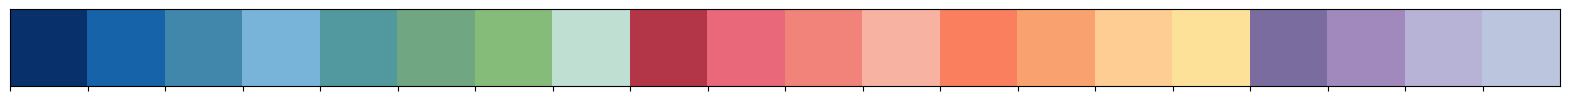

In [3]:
cls = ["#08306B", "#1663AA", "#4187AC", "#78B4D9", "#51999F", "#71A682", "#86BC79", "#BFDFD2", "#B23648", "#E9687A", "#F1837A", "#F8B2A2", "#F97F5F", "#FAA26F", "#FDCD94", "#FEE199", "#7B6C9F", "#A188BD", "#B6B3D6", "#BBC5DE"]
custom_palette = sns.color_palette(cls)
sns.palplot(custom_palette)

11327000
95625000
6542000
54184000


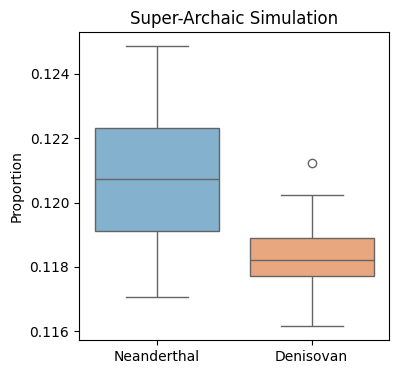

In [6]:
singer_den = []
singer_nea = []
data = pd.read_csv('results/realdata/test_simulation/nosup_model/arghmm/singerave_t31500_t15000_den.count_merge.txt',sep='\t')
data = data.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
# data = data[(data["nYRI"] < 0.2) & (data["nd10_prop"] < 0.2) & (data["nd01_prop"] < 0.2) & (data["nea_aff"] < 0.5) & (data["den_aff"] < 0.5) & (data["tot_b"] >= 10)]
s = pybedtools.BedTool.from_dataframe(data[["chromosome", "start", "end"]]).sort().merge()
# s = np.sum([interval.end - interval.start for interval in s])
data2 = pd.read_csv('results/realdata/test_simulation/nosup_model/arghmm/singerave_t15000_gbr.count_merge.txt', sep='\t')
data2.loc[(data2['nd10_prop'] > 0.2) & (data2['nd10_b'] > data2['nd01_b']), 'assign_label'] = 'NEA'
data2.loc[(data2['nd01_prop'] > 0.2) & (data2['nd10_b'] < data2['nd01_b']), 'assign_label'] = 'DEN'
data2 = data2.drop_duplicates(subset=['chromosome', 'start', 'end', 'assign_label'], keep='first')
# data2 = data2[(data2["nYRI"] < 0.2)]
subdata = data2[data2["assign_label"]=="DEN"][["chromosome", "start", "end"]].astype(int)
ss = pybedtools.BedTool.from_dataframe(subdata).sort().merge()
print(np.sum([iv.length for iv in s]))
print(np.sum([iv.length for iv in ss]))
interval = s.intersect(ss)
s = np.sum([iv.length for iv in interval])
ss = np.sum([ii.length for ii in ss])
singer_den.append(s / ss)
for s in range(1, 11):
    sdata = data[data["chromosome"] != s][["chromosome", "start", "end"]]
    ssdata = data2[data2["chromosome"] != s]
    subsdata = ssdata[ssdata["assign_label"] == "DEN"][["chromosome", "start", "end"]].astype(int)
    s = pybedtools.BedTool.from_dataframe(sdata).sort().merge()
    # s = np.sum([interval.end - interval.start for interval in s])
    ss = pybedtools.BedTool.from_dataframe(subsdata).sort().merge()
    interval = s.intersect(ss)
    s = np.sum([iv.length for iv in interval])
    ss = np.sum([ii.length for ii in ss])
    singer_den.append(s / ss)
data = pd.read_csv('results/realdata/test_simulation/nosup_model/arghmm/singerave_t31500_t15000_nea.count_merge.txt',sep='\t')
data = data.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
# data = data[(data["nYRI"] < 0.2) & (data["nd10_prop"] < 0.2) & (data["nd01_prop"] < 0.2) & (data["den_aff"] < 0.5) & (data["nea_aff"] < 0.5) & (data["tot_b"] >= 10)]
s = pybedtools.BedTool.from_dataframe(data[["chromosome", "start", "end"]]).sort().merge()
# s = np.sum([interval.end - interval.start for interval in s])
data2 = pd.read_csv('results/realdata/test_simulation/nosup_model/arghmm/singerave_t15000_gbr.count_merge.txt', sep='\t')
data2.loc[(data2['nd10_prop'] > 0.2) & (data2['nd10_b'] > data2['nd01_b']), 'assign_label'] = 'NEA'
data2.loc[(data2['nd01_prop'] > 0.2) & (data2['nd10_b'] < data2['nd01_b']), 'assign_label'] = 'DEN'
data2 = data2.drop_duplicates(subset=['chromosome', 'start', 'end', 'assign_label'], keep='first')
# data2 = data2[(data2["nYRI"] < 0.2)]
subdata = data2[data2["assign_label"]=="NEA"][["chromosome", "start", "end"]].astype(int)
ss = pybedtools.BedTool.from_dataframe(subdata).sort().merge()
print(np.sum([iv.length for iv in s]))
print(np.sum([iv.length for iv in ss]))
interval = s.intersect(ss)
s = np.sum([iv.length for iv in interval])
ss = np.sum([ii.length for ii in ss])
singer_nea.append(s / ss)
for s in range(1, 11):
    sdata = data[data["chromosome"] != s][["chromosome", "start", "end"]]
    ssdata = data2[data2["chromosome"] != s]
    subsdata = ssdata[ssdata["assign_label"] == "NEA"][["chromosome", "start", "end"]].astype(int)
    s = pybedtools.BedTool.from_dataframe(sdata).sort().merge()
    # s = np.sum([interval.end - interval.start for interval in s])
    ss = pybedtools.BedTool.from_dataframe(subsdata).sort().merge()
    interval = s.intersect(ss)
    s = np.sum([iv.length for iv in interval])
    ss = np.sum([ii.length for ii in ss])
    singer_nea.append(s / ss)

data_dict = {
    'singer_nea': singer_nea,
    'singer_den': singer_den
}
df = pd.DataFrame(data_dict)
order = ['singer_nea', 'singer_den']
plt.figure(figsize=(4, 4));
sns.boxplot(data=df, order=order, palette=[cls[3], cls[13]]);
plt.xticks([0, 1], ['Neanderthal', 'Denisovan'])
plt.ylabel('Proportion');
plt.title('Super-Archaic Simulation');
plt.savefig('images/fig4_c.pdf', bbox_inches='tight')

In [7]:
# Method 2: All pairwise comparisons (for moderate sample sizes)
print(f"\n--- Binomial Test (pairwise comparisons) ---")
# More efficient implementation for pairwise comparisons
b_matrix = df["singer_den"].to_numpy()[:, np.newaxis]  # Convert to column vector
a_matrix = df["singer_nea"].to_numpy()[np.newaxis, :]  # Convert to row vector
comparison_matrix = b_matrix > a_matrix  # Broadcasting comparison
success_count = np.sum(comparison_matrix)
total_comparisons = len(df) * len(df)
p_value_pairwise = stats.binom_test(success_count, total_comparisons, p=0.5, alternative='greater')
print(f"Pairs where b > a: {success_count} out of {total_comparisons}")
print(f"Proportion: {success_count/total_comparisons:.3f}")
print(f"p-value: {p_value_pairwise}")
print(f"log10 p-value: {np.log10(p_value_pairwise)}")
print(f"Significant at α=0.05: {p_value_pairwise < 0.05}")


--- Binomial Test (pairwise comparisons) ---
Pairs where b > a: 25 out of 121
Proportion: 0.207
p-value: 0.9999999999932785
log10 p-value: -2.9191156740132657e-12
Significant at α=0.05: False


/global/scratch/users/zhangyulin9806/tmp/ipykernel_2399716/2502183470.py:9: DeprecationWarning: 'binom_test' is deprecated in favour of 'binomtest' from version 1.7.0 and will be removed in Scipy 1.12.0.
  p_value_pairwise = stats.binom_test(success_count, total_comparisons, p=0.5, alternative='greater')


In [38]:
prec = []
rec = []
dff = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t31500_t15000_nea.count_merge.txt', sep = '\t')
dff = dff.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
df = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t31500_t15000_den.count_merge.txt', sep = '\t')
df = df.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
a = len(df[(df["nd10_prop"] == 0) & (df["nd01_prop"] < 0.1) & (df['nd00_prop'] > 0.9) & (df["nYRI"] < 0.1) & (df["length(bp)"] > dff["length(bp)"].mean()) & (df["tot_b"] > dff["tot_b"].mean()) & (df["truth_assign"].str.contains("SUPER", case=True, na=False))])
b = len(df[(df["nd10_prop"] == 0) & (df["nd01_prop"] < 0.1) & (df['nd00_prop'] > 0.9) & (df["nYRI"] < 0.1) & (df["length(bp)"] > dff["length(bp)"].mean()) & (df["tot_b"] > dff["tot_b"].mean())])
c = len(df[df["truth_assign"].str.contains("SUPER", case=True, na=False)])
print(a / b, a / c, a, b, c)
prec.append(a / b)
rec.append(a / c)
for i in range(1, 11):
    subdf = df[df["chromosome"] != i]
    a = len(subdf[(subdf["nd10_prop"] == 0) & (subdf["nd01_prop"] < 0.1) & (subdf['nd00_prop'] > 0.9) & (subdf["nYRI"] < 0.1) & (subdf["length(bp)"] > dff["length(bp)"].mean()) & (subdf["tot_b"] > dff["tot_b"].mean()) & (subdf["truth_assign"].str.contains("SUPER", case=True, na=False))])
    b = len(subdf[(subdf["nd10_prop"] == 0) & (subdf["nd01_prop"] < 0.1) & (subdf['nd00_prop'] > 0.9) & (subdf["nYRI"] < 0.1) & (subdf["length(bp)"] > dff["length(bp)"].mean()) & (subdf["tot_b"] > dff["tot_b"].mean())])
    c = len(subdf[subdf["truth_assign"].str.contains("SUPER", case=True, na=False)])
    print(a / b, a / c, a, b, c)
    prec.append(a / b)
    rec.append(a / c)
np.mean(prec), np.percentile(prec, 2.5), np.percentile(prec, 97.5), np.mean(rec), np.percentile(rec, 2.5), np.percentile(rec, 97.5)

0.7012987012987013 0.2755102040816326 54 77 196
0.75 0.2896551724137931 42 56 145
0.6857142857142857 0.2681564245810056 48 70 179
0.6567164179104478 0.2619047619047619 44 67 168
0.684931506849315 0.2777777777777778 50 73 180
0.6891891891891891 0.2786885245901639 51 74 183
0.7066666666666667 0.2774869109947644 53 75 191
0.7246376811594203 0.2808988764044944 50 69 178
0.7014925373134329 0.2655367231638418 47 67 177
0.6986301369863014 0.27419354838709675 51 73 186
0.7246376811594203 0.2824858757062147 50 69 177


(0.70217407311338,
 0.6637701901451646,
 0.7436594202898551,
 0.2756631636368679,
 0.2628127522195319,
 0.2878628482368985)

In [30]:
dff = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t31500_nea.count_merge.txt', sep = '\t')
dff = dff.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
df = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t31500_den.count_merge.txt', sep = '\t')
df = df.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
s = df[(df["nd10_prop"] == 0) & (df["nd01_prop"] < 0.1) & (df['nd00_prop'] > 0.9) & (df["nYRI"] < 0.1) & (df["length(bp)"] > dff["length(bp)"].mean()) & (df["tot_b"] > dff["tot_b"].mean())][["chromosome", "start", "end"]]
s = pybedtools.BedTool.from_dataframe(s).sort().merge()
s = np.sum([interval.end - interval.start for interval in s])
data2 = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t15000_gbr.count_merge.txt', sep='\t')
data2 = data2.drop_duplicates(subset=['chromosome', 'start', 'end', 'assign_label'], keep='first')
subdata = data2[data2["assign_label"]=="DEN"][["chromosome", "start", "end"]]
ss = '\n'.join(subdata.astype(str).agg('\t'.join, axis=1))
ss = pybedtools.BedTool(ss, from_string=True).sort().merge()
ss = np.sum([interval.end - interval.start for interval in ss])
print(s / ss)

0.017351063940916546


/global/scratch/users/zhangyulin9806/tmp/ipykernel_2212297/2515457404.py:8: DtypeWarning: Columns (52,53,54,55,56) have mixed types. Specify dtype option on import or set low_memory=False.
  data2 = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t15000_gbr.count_merge.txt', sep='\t')


In [37]:
data = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/treeID.txt',sep='\t')
df = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t31500_den.count_merge.txt', sep = '\t')
df = df.drop_duplicates(subset=['chromosome', 'start', 'end', 'ID'], keep='first')
dff = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t31500_nea.count_merge.txt', sep = '\t')
dff = dff.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
df = df[(df["nd10_prop"] == 0) & (df["nd01_prop"] < 0.1) & (df['nd00_prop'] > 0.9) & (df["nYRI"] < 0.1) & (df["length(bp)"] > dff["length(bp)"].mean()) & (df["tot_b"] > dff["tot_b"].mean())]
df = df[["chromosome", "start", "end", "length(bp)", "ID"]]
df = data[data["ID"] < 100].merge(df, on='ID', how='left').fillna(0)
a = df.groupby('ID').agg({'length(bp)': 'sum'}).reset_index()
data2 = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t15000_gbr.count_merge.txt', sep='\t')
subdata = data2[data2["assign_label"]=="DEN"]
subdata = subdata[["chromosome", "start", "end", "length(bp)", "ID"]]
subdata = data[data["ID"] < 100].merge(subdata, on='ID', how='left').fillna(0)
b = subdata.groupby('ID').agg({'length(bp)': 'sum'}).reset_index()
np.mean(a["length(bp)"] / b["length(bp)"])

/global/scratch/users/zhangyulin9806/tmp/ipykernel_2212297/3846190751.py:10: DtypeWarning: Columns (52,53,54,55,56) have mixed types. Specify dtype option on import or set low_memory=False.
  data2 = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t15000_gbr.count_merge.txt', sep='\t')


0.014049815532555571

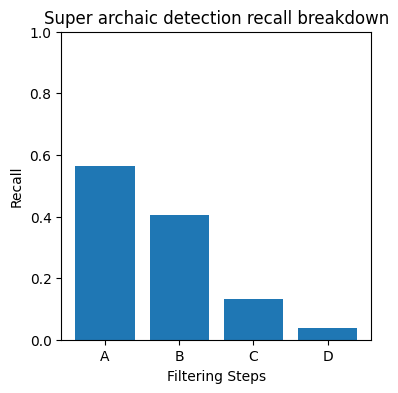

In [39]:
labels = [
    "A", # called as archaic by ARGHMM
    "B", # classified as DEN
    "C", # >10kbp, 0.01cM, upper end >31500
    "D", # nd10_prop == 0, nd01_prop < 0.1, nd00_prop > 0.9, nYRI < 0.1, length > NEA mean, tot_b > NEA mean
]
data = [0.5636858208079537, 0.5636858208079537 * 0.717, 0.133, 0.133 * 0.277]
plt.figure(figsize=(4, 4));
plt.bar(labels, data)
plt.ylim(0, 1)
plt.ylabel('Recall');
plt.xlabel('Filtering Steps');
plt.title('Super archaic detection recall breakdown');
plt.savefig('images/figS8_5.pdf', bbox_inches='tight')

In [1]:
0.133 * 0.277

0.036841000000000006

# haplotype length

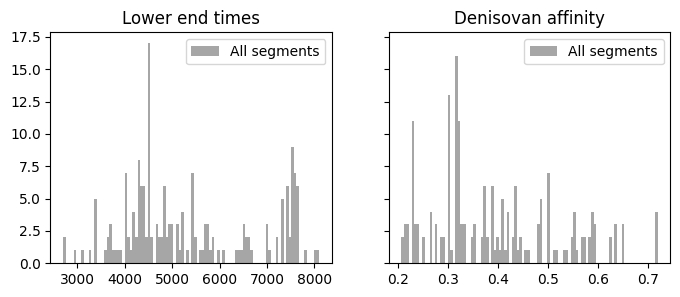

In [ ]:
df = pd.read_csv("results/realdata/test_simulation/eur_ghost_model/arghmm/singerave_t15000_gbr.count_merge.txt", sep='\t')
# df = df[df["length(bp)"] >= 150000]
df["nd01_prop"] = df["nd01_prop"].astype(float)
df = df[(df["nd01_prop"] > 0.2) & (df["nd01_b"] > df["nd10_b"])]
df["mt1s"] = df["t1s"].apply(lambda x: np.median([float(i) for i in x.split(",")]))
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True);
ax[0].hist(df["mt1s"], bins=100, label = "All segments", alpha=0.7, color='gray')
ax[1].hist(df["nd01_prop"], bins=100, label = "All segments", alpha=0.7, color='gray')
ax[0].set_title("Lower end times")
ax[1].set_title("Denisovan affinity")
ax[0].legend()
ax[1].legend()

[1] Improvement: 1.0812530517578125, Time: 0.0008519s
[2] Improvement: 0.187591552734375, Time: 0.0009291s
[3] Improvement: 0.0887603759765625, Time: 0.0008314s
m1: 5672.789175602384, m2: 4750.832640020948, v1: 2013072.1345441842, v2: 1270218.4351614409
m1: 0.09184791455758302, m2: 0.09009356660230187


Text(0.47, 1, 'Simulation EAS')

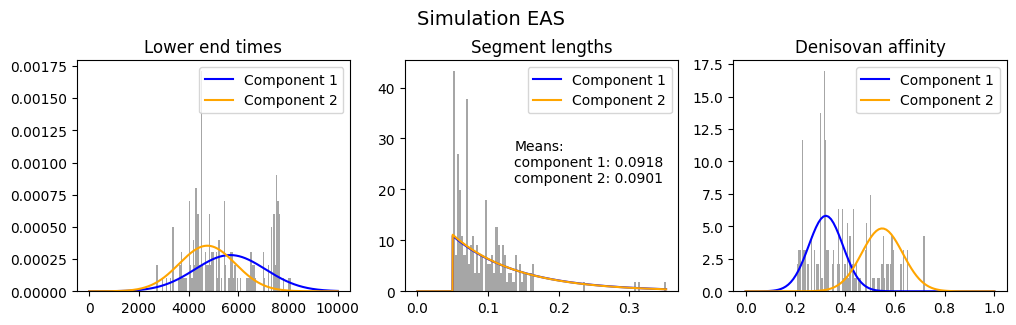

In [ ]:
data = df["nd01_prop"].astype(float).values.reshape(-1, 1)
d1 = Normal()
d2 = Normal()
model = GeneralMixtureModel([d1, d2], verbose=True).fit(data)
dt1s = df["mt1s"].astype(float).to_numpy()
mprob = np.array(model.predict_proba(data))
dm1 = np.sum(mprob[:, 0] * dt1s) / np.sum(mprob[:, 0])
dm2 = np.sum(mprob[:, 1] * dt1s) / np.sum(mprob[:, 1])
dv1 = np.sum(mprob[:, 0] * (dt1s - dm1) ** 2) / np.sum(mprob[:, 0])
dv2 = np.sum(mprob[:, 1] * (dt1s - dm2) ** 2) / np.sum(mprob[:, 1])
print(f"m1: {dm1}, m2: {dm2}, v1: {dv1}, v2: {dv2}")
fig, ax = plt.subplots(1, 3, figsize=(12, 3));
x = np.linspace(0, 15000, 15000).reshape(-1, 1)
ax[0].hist(dt1s, bins=100, density=True, alpha=0.7, color='gray')
ax[0].plot(x, stats.norm.pdf(x, dm1, np.sqrt(dv1)), color='blue', label='Component 1')
ax[0].plot(x, stats.norm.pdf(x, dm2, np.sqrt(dv2)), color='orange', label='Component 2')
ax[0].set_title("Lower end times")
ax[0].legend()
lts = df["length(cM)"].astype(float).to_numpy()
mprob = np.array(model.predict_proba(data))
dm1 = np.sum(mprob[:, 0] * lts) / np.sum(mprob[:, 0])
dm2 = np.sum(mprob[:, 1] * lts) / np.sum(mprob[:, 1])
print(f"m1: {dm1}, m2: {dm2}")
x = np.linspace(0, max(lts), 1000).reshape(-1, 1)
ax[1].hist(lts, bins=100, density=True, alpha=0.7, color='gray')
ax[1].plot(x, stats.expon.pdf(x, scale = dm1, loc = 5e-2), color='blue', label='Component 1')
ax[1].plot(x, stats.expon.pdf(x, scale = dm2, loc = 5e-2), color='orange', label='Component 2')
# ax[1].text(200000, 1e-5, f"Means:\ncomponent 1: {dm1:.0f}\ncomponent 2: {dm2:.0f}", fontsize=10)
ax[1].text(0.4, 0.47, f"Means:\ncomponent 1: {dm1:.4f}\ncomponent 2: {dm2:.4f}", transform=ax[1].transAxes, fontsize=10)
ax[1].set_title("Segment lengths")
ax[1].legend()
x = np.linspace(0, 1, 100).reshape(-1, 1)
ax[2].hist(data, bins=100, density=True, alpha=0.7, color='gray')
ax[2].plot(x, stats.norm.pdf(x, d1.means[0], np.sqrt(d1.covs[0])), color='blue', label='Component 1')
ax[2].plot(x, stats.norm.pdf(x, d2.means[0], np.sqrt(d2.covs[0])), color='orange', label='Component 2')
ax[2].set_title("Denisovan affinity")
ax[2].legend()
fig.text(0.47, 1, "Simulation EAS", ha='center', fontsize=14)

# affinity plots

In [47]:
df = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t15000_gbr.count_merge.txt', sep = '\t')
df = df.drop_duplicates(['chromosome','start','end'], keep='last')
df = df[df[["ND00", "ND10", "ND01", "ND11"]].astype('int').sum(axis = 1) > 30]
df['nea_aff'] = (df['ND10']+ df['ND11']) / (df['ND10'] + df['ND01'] + df['ND00'] + df['ND11'])
df['den_aff'] = (df['ND01']+ df['ND11']) / (df['ND10'] + df['ND01'] + df['ND00'] + df['ND11'])
df.loc[(df['nd10_prop'] > 0.2) & (df['nd10_b'] > df['nd01_b']), 'assign_label'] = 'NEA'
df.loc[(df['nd01_prop'] > 0.2) & (df['nd10_b'] < df['nd01_b']), 'assign_label'] = 'DEN'
df.loc[(df['nd00_prop'] > 0.8), 'assign_label'] = 'Ghost'

/global/scratch/users/zhangyulin9806/tmp/ipykernel_2212297/3290368040.py:1: DtypeWarning: Columns (52,53,54,55,56) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t15000_gbr.count_merge.txt', sep = '\t')


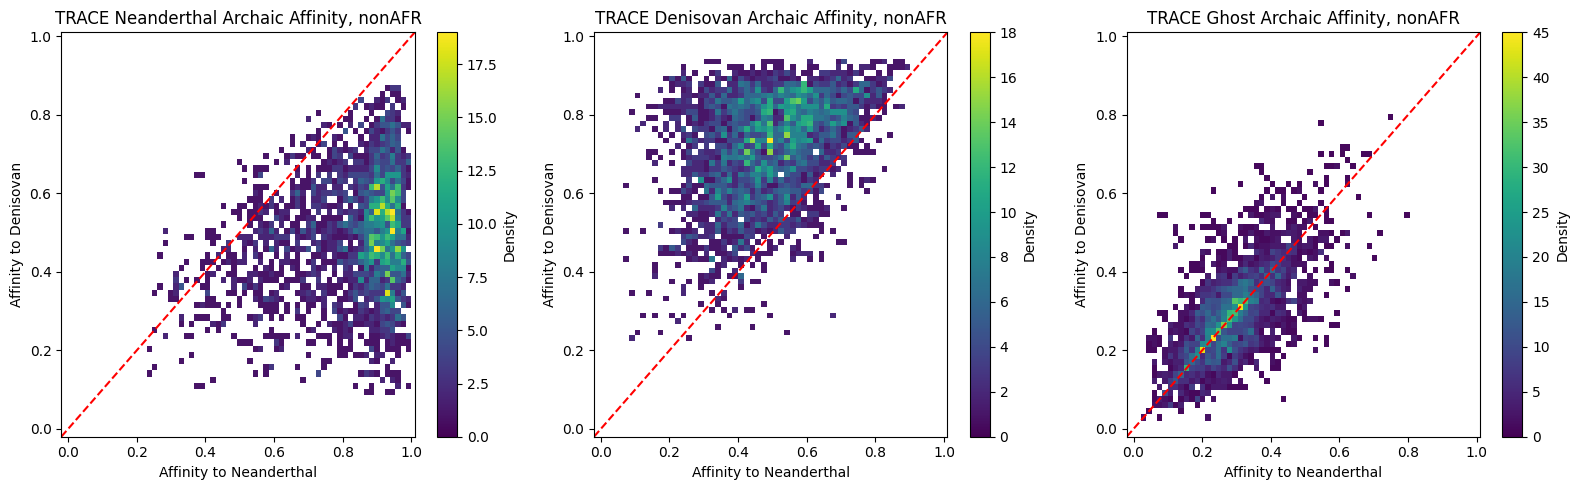

In [48]:
dff_nea = df[df["assign_label"] == "NEA"]
dff_den = df[df["assign_label"] == "DEN"]
dff_ghost = df[df["assign_label"] == "Ghost"]
# dff_nea = df[df["truth_assign"] == "Neanderthal"]
# dff_den = df[df["truth_assign"] == "Denisova"]
# dff_ghost = df[(df["truth_assign"] == "Ghost")]
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
sns.histplot(x=dff_nea['nea_aff'], y=dff_nea['den_aff'], bins=50, cmap='viridis', cbar=True, cbar_kws={'label': 'Density'}, ax=ax[0])
ax[0].axline((0, 0), slope=1, color='red', linestyle='--')
sns.histplot(x=dff_den['nea_aff'], y=dff_den['den_aff'], bins=50, cmap='viridis', cbar=True, cbar_kws={'label': 'Density'}, ax=ax[1])
ax[1].axline((0, 0), slope=1, color='red', linestyle='--')
sns.histplot(x=dff_ghost['nea_aff'], y=dff_ghost['den_aff'], bins=50, cmap='viridis', cbar=True, cbar_kws={'label': 'Density'}, ax=ax[2])
ax[2].axline((0, 0), slope=1, color='red', linestyle='--')
ax[0].set_xlabel('Affinity to Neanderthal')
ax[1].set_xlabel('Affinity to Neanderthal')
ax[2].set_xlabel('Affinity to Neanderthal')
ax[0].set_ylabel('Affinity to Denisovan')
ax[1].set_ylabel('Affinity to Denisovan')
ax[2].set_ylabel('Affinity to Denisovan')
ax[0].set_title('TRACE Neanderthal Archaic Affinity, nonAFR')
ax[1].set_title('TRACE Denisovan Archaic Affinity, nonAFR')
ax[2].set_title('TRACE Ghost Archaic Affinity, nonAFR')
ax[0].set_ylim([-0.02, 1.01])
ax[1].set_ylim([-0.02, 1.01])
ax[2].set_ylim([-0.02, 1.01])
ax[0].set_xlim([-0.02, 1.01])
ax[1].set_xlim([-0.02, 1.01])
ax[2].set_xlim([-0.02, 1.01])
plt.tight_layout()
plt.savefig('images/figS8_2b.pdf', bbox_inches='tight')

In [43]:
df = pd.read_csv('results/realdata/test_simulation/eur_ghost_model/arghmm/singerave_t15000_yri.count_merge.txt', sep = '\t')
df = df.drop_duplicates(['chromosome','start','end'], keep='last')
df = df[df[["ND00", "ND10", "ND01", "ND11"]].astype('int').sum(axis = 1) > 30]
df['nea_aff'] = (df['ND10']+ df['ND11']) / (df['ND10'] + df['ND01'] + df['ND00'] + df['ND11'])
df['den_aff'] = (df['ND01']+ df['ND11']) / (df['ND10'] + df['ND01'] + df['ND00'] + df['ND11'])
df.loc[(df['nd10_prop'] > 0.2) & (df['nd10_b'] > df['nd01_b']), 'assign_label'] = 'NEA'
df.loc[(df['nd01_prop'] > 0.2) & (df['nd10_b'] < df['nd01_b']), 'assign_label'] = 'DEN'
df.loc[(df['nd00_prop'] > 0.8), 'assign_label'] = 'Ghost'

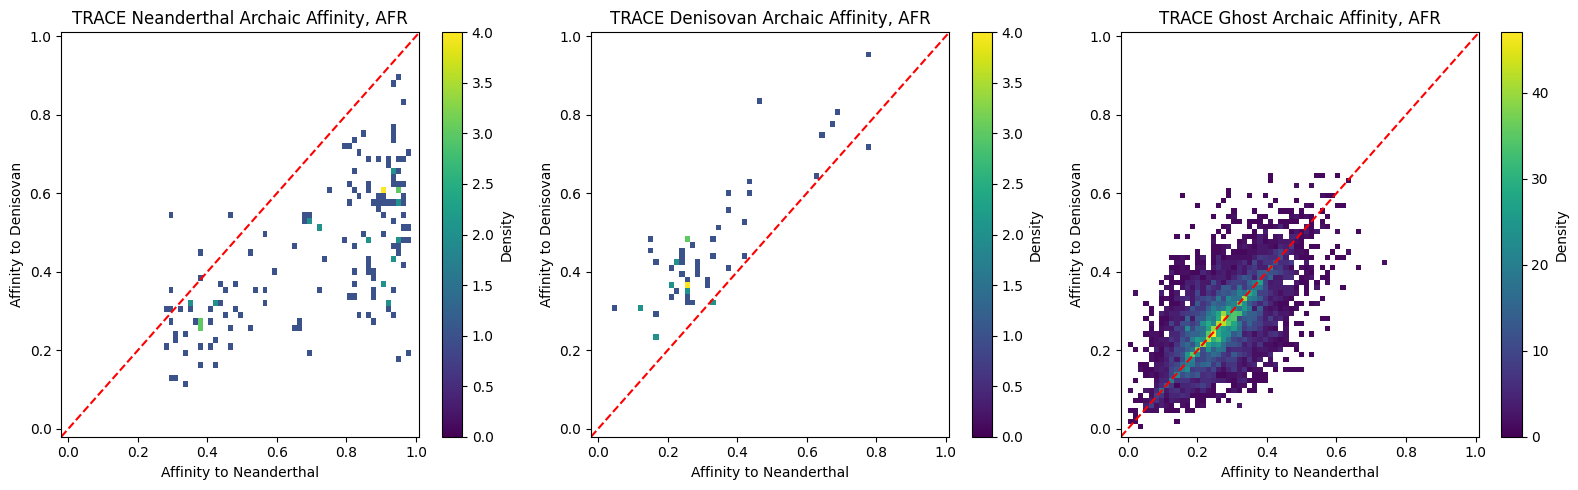

In [44]:
dff_nea = df[df["assign_label"] == "NEA"]
dff_den = df[df["assign_label"] == "DEN"]
dff_ghost = df[df["assign_label"] == "Ghost"]
# dff_nea = df[df["truth_assign"] == "Neanderthal"]
# dff_den = df[df["truth_assign"] == "Denisova"]
# dff_ghost = df[(df["truth_assign"] == "Ghost")]
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
sns.histplot(x=dff_nea['nea_aff'], y=dff_nea['den_aff'], bins=50, cmap='viridis', cbar=True, cbar_kws={'label': 'Density'}, ax=ax[0])
ax[0].axline((0, 0), slope=1, color='red', linestyle='--')
sns.histplot(x=dff_den['nea_aff'], y=dff_den['den_aff'], bins=50, cmap='viridis', cbar=True, cbar_kws={'label': 'Density'}, ax=ax[1])
ax[1].axline((0, 0), slope=1, color='red', linestyle='--')
sns.histplot(x=dff_ghost['nea_aff'], y=dff_ghost['den_aff'], bins=50, cmap='viridis', cbar=True, cbar_kws={'label': 'Density'}, ax=ax[2])
ax[2].axline((0, 0), slope=1, color='red', linestyle='--')
ax[0].set_xlabel('Affinity to Neanderthal')
ax[1].set_xlabel('Affinity to Neanderthal')
ax[2].set_xlabel('Affinity to Neanderthal')
ax[0].set_ylabel('Affinity to Denisovan')
ax[1].set_ylabel('Affinity to Denisovan')
ax[2].set_ylabel('Affinity to Denisovan')
ax[0].set_title('TRACE Neanderthal Archaic Affinity, AFR')
ax[1].set_title('TRACE Denisovan Archaic Affinity, AFR')
ax[2].set_title('TRACE Ghost Archaic Affinity, AFR')
ax[0].set_ylim([-0.02, 1.01])
ax[1].set_ylim([-0.02, 1.01])
ax[2].set_ylim([-0.02, 1.01])
ax[0].set_xlim([-0.02, 1.01])
ax[1].set_xlim([-0.02, 1.01])
ax[2].set_xlim([-0.02, 1.01])
plt.tight_layout()
plt.savefig('images/figS5_3b.pdf', bbox_inches='tight')

# SFS, CSFS

In [10]:
def process_daf_data(dff_nea, colname_daf='DAF_GBRYRI', condition="ND10"):
    # Split and explode in one go
    exploded = []
    for _, row in dff_nea.iterrows():
        mks = row['dsnps_marks'].split(",")
        daf_gy = row[colname_daf].split(",")
        min_len = len(mks)
        for i in range(min_len):
            exploded.append({
                'daf': float(daf_gy[i]),
                'mk': mks[i]
            })
    result_df = pd.DataFrame(exploded)
    daf_gbr_yri = result_df['daf'].values
    daf_gbr_yri_c = result_df[result_df['mk'].isin([condition, 'ND11'])]['daf'].values
    return daf_gbr_yri, daf_gbr_yri_c

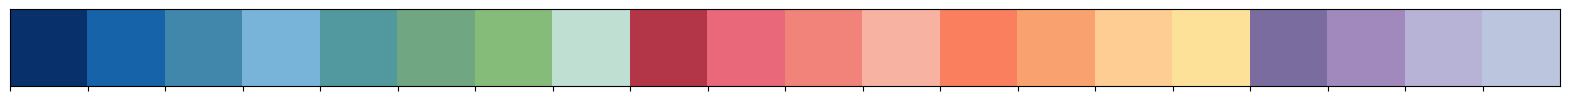

In [35]:
cls = ["#08306B", "#1663AA", "#4187AC", "#78B4D9", "#51999F", "#71A682", "#86BC79", "#BFDFD2", "#B23648", "#E9687A", "#F1837A", "#F8B2A2", "#F97F5F", "#FAA26F", "#FDCD94", "#FEE199", "#7B6C9F", "#A188BD", "#B6B3D6", "#BBC5DE"]
custom_palette = sns.color_palette(cls)
sns.palplot(custom_palette)

/global/scratch/users/zhangyulin9806/tmp/ipykernel_2212297/3675504254.py:1: DtypeWarning: Columns (52,53,54,55,56) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("results/realdata/test_simulation/super_model/arghmm/singerave_t15000_gbr.count_merge.txt", sep="\t")


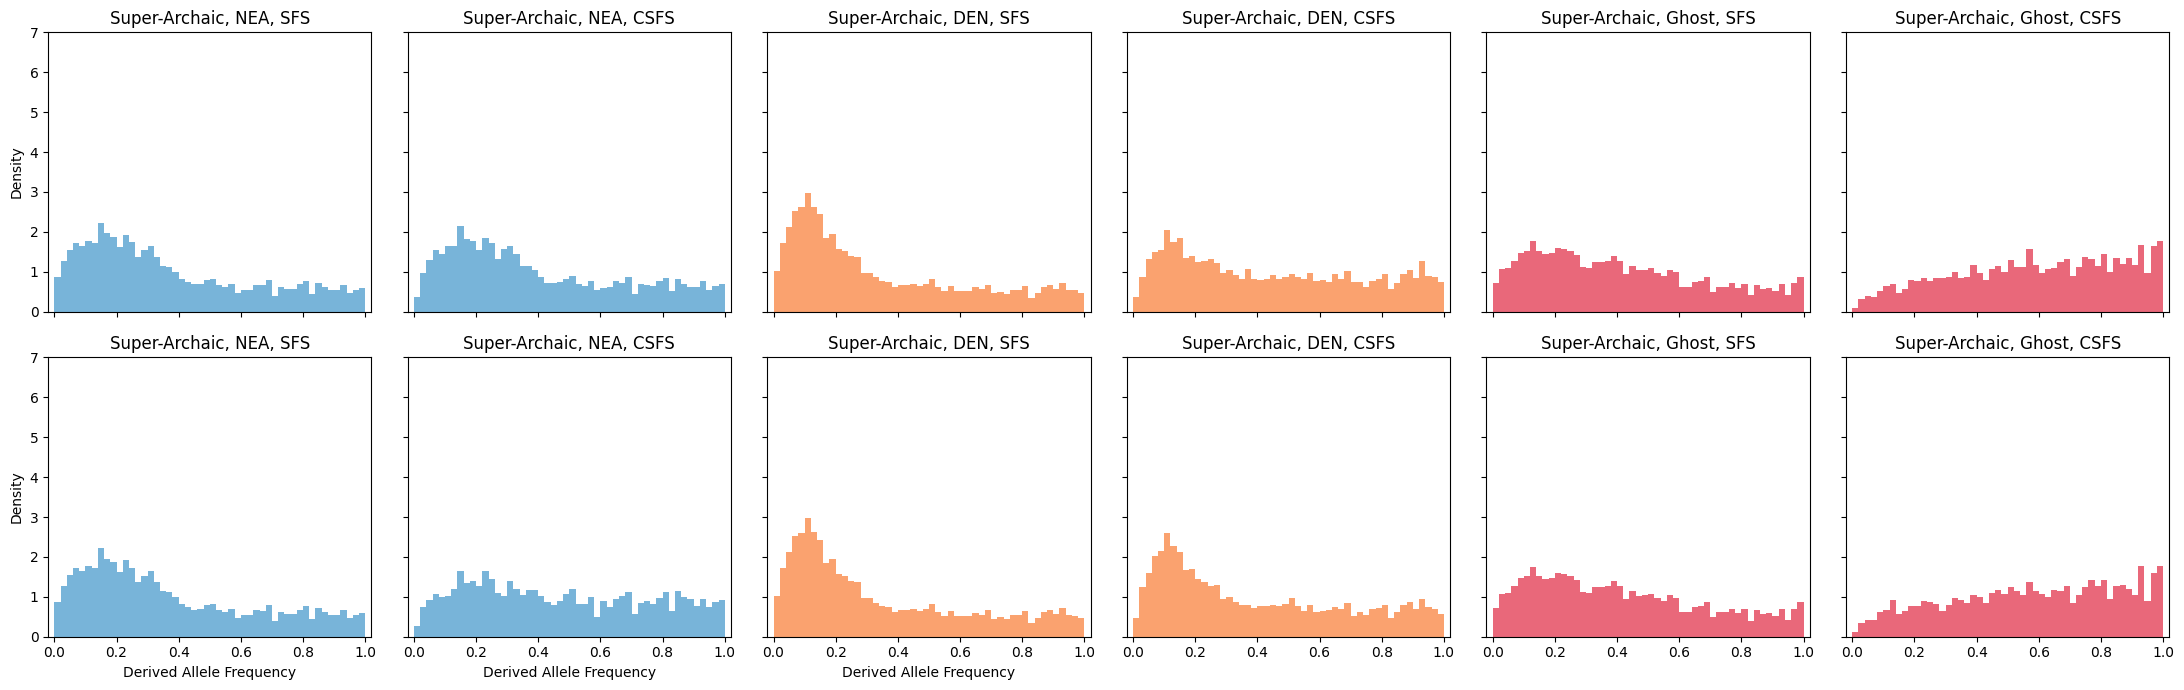

In [17]:
df = pd.read_csv("results/realdata/test_simulation/super_model/arghmm/singerave_t15000_gbr.count_merge.txt", sep="\t")
df = df.drop_duplicates(['chromosome','start','end'], keep='last')
df = df[df[["ND00", "ND10", "ND01", "ND11"]].astype('int').sum(axis = 1) > 30]
df['nea_aff'] = (df['ND10']+ df['ND11']) / (df['ND10'] + df['ND01'] + df['ND00'] + df['ND11'])
df['den_aff'] = (df['ND01']+ df['ND11']) / (df['ND10'] + df['ND01'] + df['ND00'] + df['ND11'])
df.loc[(df['nd10_prop'] > 0.2) & (df['nd10_b'] > df['nd01_b']), 'assign_label'] = 'NEA'
df.loc[(df['nd01_prop'] > 0.2) & (df['nd10_b'] < df['nd01_b']), 'assign_label'] = 'DEN'
df.loc[(df['nd00_prop'] > 0.8), 'assign_label'] = 'Ghost'
dff_nea = df[df["assign_label"] == "NEA"]
dff_den = df[df["assign_label"] == "DEN"]
dff_ghost = df[df["assign_label"] == "Ghost"]
fig, ax = plt.subplots(2, 6, figsize=(22, 7), sharex=True, sharey=True)
daf_gbr_yri, daf_gbr_yri_c = process_daf_data(dff_nea, 'DAF_GBR', condition="ND10")
daf_gbr_yri = np.array(daf_gbr_yri)
daf_gbr_yri = daf_gbr_yri[(daf_gbr_yri > 0) & (daf_gbr_yri < 1)]
daf_gbr_yri_c = np.array(daf_gbr_yri_c)
daf_gbr_yri_c = daf_gbr_yri_c[(daf_gbr_yri_c > 0) & (daf_gbr_yri_c < 1)]
ax[0][0].hist(daf_gbr_yri, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[3], label='OCN', density=True)
ax[0][1].hist(daf_gbr_yri_c, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[3], label='OCN', density=True)
ax[0][0].set_title('Super-Archaic, NEA, SFS')
ax[0][1].set_title('Super-Archaic, NEA, CSFS')

daf_ghost_yri, daf_ghost_yri_c = process_daf_data(dff_den, 'DAF_GBR', condition="ND10")
daf_ghost_yri = np.array(daf_ghost_yri)
daf_ghost_yri = daf_ghost_yri[(daf_ghost_yri > 0) & (daf_ghost_yri < 1)]
daf_ghost_yri_c = np.array(daf_ghost_yri_c)
daf_ghost_yri_c = daf_ghost_yri_c[(daf_ghost_yri_c > 0) & (daf_ghost_yri_c < 1)]
ax[0][2].hist(daf_ghost_yri, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[13], label='OCN', density=True)
ax[0][3].hist(daf_ghost_yri_c, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[13], label='OCN', density=True)
ax[0][2].set_title('Super-Archaic, DEN, SFS')
ax[0][3].set_title('Super-Archaic, DEN, CSFS')

daf_ghost_yri, daf_ghost_yri_c = process_daf_data(dff_ghost, 'DAF_GBR', condition="ND10")
daf_ghost_yri = np.array(daf_ghost_yri)
daf_ghost_yri = daf_ghost_yri[(daf_ghost_yri > 0) & (daf_ghost_yri < 1)]
daf_ghost_yri_c = np.array(daf_ghost_yri_c)
daf_ghost_yri_c = daf_ghost_yri_c[(daf_ghost_yri_c > 0) & (daf_ghost_yri_c < 1)]
ax[0][4].hist(daf_ghost_yri, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[9], label='OCN', density=True)
ax[0][5].hist(daf_ghost_yri_c, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[9], label='OCN', density=True)
ax[0][4].set_title('Super-Archaic, Ghost, SFS')
ax[0][5].set_title('Super-Archaic, Ghost, CSFS')

daf_gbr_yri, daf_gbr_yri_c = process_daf_data(dff_nea, 'DAF_GBR', condition="ND01")
daf_gbr_yri = np.array(daf_gbr_yri)
daf_gbr_yri = daf_gbr_yri[(daf_gbr_yri > 0) & (daf_gbr_yri < 1)]
daf_gbr_yri_c = np.array(daf_gbr_yri_c)
daf_gbr_yri_c = daf_gbr_yri_c[(daf_gbr_yri_c > 0) & (daf_gbr_yri_c < 1)]
ax[1][0].hist(daf_gbr_yri, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[3], label='OCN', density=True)
ax[1][1].hist(daf_gbr_yri_c, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[3], label='OCN', density=True)
ax[1][0].set_title('Super-Archaic, NEA, SFS')
ax[1][1].set_title('Super-Archaic, NEA, CSFS')

daf_ghost_yri, daf_ghost_yri_c = process_daf_data(dff_den, 'DAF_GBR', condition="ND01")
daf_ghost_yri = np.array(daf_ghost_yri)
daf_ghost_yri = daf_ghost_yri[(daf_ghost_yri > 0) & (daf_ghost_yri < 1)]
daf_ghost_yri_c = np.array(daf_ghost_yri_c)
daf_ghost_yri_c = daf_ghost_yri_c[(daf_ghost_yri_c > 0) & (daf_ghost_yri_c < 1)]
ax[1][2].hist(daf_ghost_yri, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[13], label='OCN', density=True)
ax[1][3].hist(daf_ghost_yri_c, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[13], label='OCN', density=True)
ax[1][2].set_title('Super-Archaic, DEN, SFS')
ax[1][3].set_title('Super-Archaic, DEN, CSFS')

daf_ghost_yri, daf_ghost_yri_c = process_daf_data(dff_ghost, 'DAF_GBR', condition="ND01")
daf_ghost_yri = np.array(daf_ghost_yri)
daf_ghost_yri = daf_ghost_yri[(daf_ghost_yri > 0) & (daf_ghost_yri < 1)]
daf_ghost_yri_c = np.array(daf_ghost_yri_c)
daf_ghost_yri_c = daf_ghost_yri_c[(daf_ghost_yri_c > 0) & (daf_ghost_yri_c < 1)]
ax[1][4].hist(daf_ghost_yri, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[9], label='OCN', density=True)
ax[1][5].hist(daf_ghost_yri_c, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[9], label='OCN', density=True)
ax[1][4].set_title('Super-Archaic, Ghost, SFS')
ax[1][5].set_title('Super-Archaic, Ghost, CSFS')

ax[0][0].set_xlim(-0.02, 1.02)
ax[0][0].set_ylim(0, 7)
ax[1][0].set_xlabel('Derived Allele Frequency')
ax[1][1].set_xlabel('Derived Allele Frequency')
ax[1][2].set_xlabel('Derived Allele Frequency')
ax[0][0].set_ylabel('Density')
ax[1][0].set_ylabel('Density')
plt.tight_layout()
plt.savefig('images/figS8_4.pdf', bbox_inches='tight')

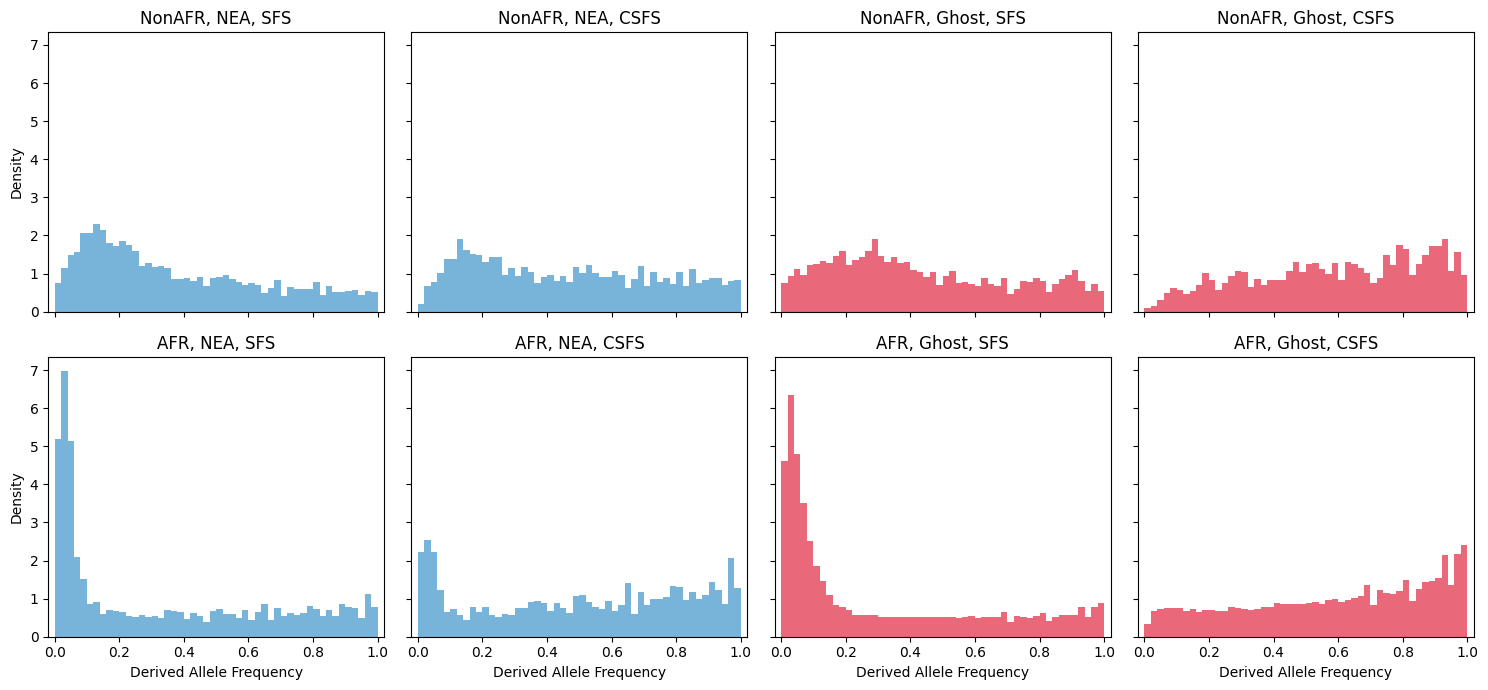

In [ ]:
df = pd.read_csv("results/realdata/test_simulation/eur_ghost_human_model/arghmm/singerave_t15000_gbr.count_merge.txt", sep="\t")
df = df.drop_duplicates(['chromosome','start','end'], keep='last')
df = df[df[["ND00", "ND10", "ND01", "ND11"]].astype('int').sum(axis = 1) > 30]
df['nea_aff'] = (df['ND10']+ df['ND11']) / (df['ND10'] + df['ND01'] + df['ND00'] + df['ND11'])
df['den_aff'] = (df['ND01']+ df['ND11']) / (df['ND10'] + df['ND01'] + df['ND00'] + df['ND11'])
# dff_nea = df[df["assign_label"] == "NEA"]
# dff_den = df[df["assign_label"] == "DEN"]
# dff_ghost = df[df["assign_label"] == "Ghost"]
dff_nea = df[df["truth_assign"] == "Neanderthal"]
dff_den = df[df["truth_assign"] == "Denisova"]
dff_ghost = df[(df["truth_assign"] == "Ghost")]
fig, ax = plt.subplots(2, 4, figsize=(15, 7), sharex=True, sharey=True)
daf_gbr_yri, daf_gbr_yri_c = process_daf_data(dff_nea, 'DAF_GBR', condition="ND01")
daf_gbr_yri = np.array(daf_gbr_yri)
daf_gbr_yri = daf_gbr_yri[(daf_gbr_yri > 0) & (daf_gbr_yri < 1)]
daf_gbr_yri_c = np.array(daf_gbr_yri_c)
daf_gbr_yri_c = daf_gbr_yri_c[(daf_gbr_yri_c > 0) & (daf_gbr_yri_c < 1)]
ax[0][0].hist(daf_gbr_yri, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[3], label='EUR', density=True)
ax[0][1].hist(daf_gbr_yri_c, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[3], label='EUR', density=True)
ax[0][0].set_title('NonAFR, NEA, SFS')
ax[0][1].set_title('NonAFR, NEA, CSFS')

daf_ghost_yri, daf_ghost_yri_c = process_daf_data(dff_ghost, 'DAF_GBR', condition="ND01")
daf_ghost_yri = np.array(daf_ghost_yri)
daf_ghost_yri = daf_ghost_yri[(daf_ghost_yri > 0) & (daf_ghost_yri < 1)]
daf_ghost_yri_c = np.array(daf_ghost_yri_c)
daf_ghost_yri_c = daf_ghost_yri_c[(daf_ghost_yri_c > 0) & (daf_ghost_yri_c < 1)]
ax[0][2].hist(daf_ghost_yri, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[9], label='EUR', density=True)
ax[0][3].hist(daf_ghost_yri_c, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[9], label='EUR', density=True)
ax[0][2].set_title('NonAFR, Ghost, SFS')
ax[0][3].set_title('NonAFR, Ghost, CSFS')

df = pd.read_csv("results/realdata/test_simulation/eur_ghost_model/arghmm/singerave_t15000_yri.count_merge.txt", sep="\t")
df = df.drop_duplicates(['chromosome','start','end'], keep='last')
df = df[df[["ND00", "ND10", "ND01", "ND11"]].astype('int').sum(axis = 1) > 30]
df['nea_aff'] = (df['ND10']+ df['ND11']) / (df['ND10'] + df['ND01'] + df['ND00'] + df['ND11'])
df['den_aff'] = (df['ND01']+ df['ND11']) / (df['ND10'] + df['ND01'] + df['ND00'] + df['ND11'])
# dff_nea = df[df["assign_label"] == "NEA"]
# dff_den = df[df["assign_label"] == "DEN"]
# dff_ghost = df[df["assign_label"] == "Ghost"]
dff_nea = df[df["truth_assign"] == "Neanderthal"]
dff_den = df[df["truth_assign"] == "Denisova"]
dff_ghost = df[(df["truth_assign"] == "Ghost")]

daf_ghost_yri, daf_ghost_yri_c = process_daf_data(dff_nea, 'DAF_YRI', condition="ND01")
daf_ghost_yri = np.array(daf_ghost_yri)
daf_ghost_yri = daf_ghost_yri[(daf_ghost_yri > 0) & (daf_ghost_yri < 1)]
daf_ghost_yri_c = np.array(daf_ghost_yri_c)
daf_ghost_yri_c = daf_ghost_yri_c[(daf_ghost_yri_c > 0) & (daf_ghost_yri_c < 1)]
ax[1][0].hist(daf_ghost_yri, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[3], label='YRI', density=True)
ax[1][1].hist(daf_ghost_yri_c, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[3], label='YRI', density=True)
ax[1][0].set_title('AFR, NEA, SFS')
ax[1][1].set_title('AFR, NEA, CSFS')

daf_ghost_yri, daf_ghost_yri_c = process_daf_data(dff_ghost, 'DAF_YRI', condition="ND01")
daf_ghost_yri = np.array(daf_ghost_yri)
daf_ghost_yri = daf_ghost_yri[(daf_ghost_yri > 0) & (daf_ghost_yri < 1)]
daf_ghost_yri_c = np.array(daf_ghost_yri_c)
daf_ghost_yri_c = daf_ghost_yri_c[(daf_ghost_yri_c > 0) & (daf_ghost_yri_c < 1)]
ax[1][2].hist(daf_ghost_yri, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[9], label='YRI', density=True)
ax[1][3].hist(daf_ghost_yri_c, bins=np.arange(0, (1 + 1/50), 1/50), color=cls[9], label='YRI', density=True)
ax[1][2].set_title('AFR, Ghost, SFS')
ax[1][3].set_title('AFR, Ghost, CSFS')

ax[0][0].set_xlim(-0.02, 1.02)
ax[1][0].set_xlabel('Derived Allele Frequency')
ax[1][1].set_xlabel('Derived Allele Frequency')
ax[1][2].set_xlabel('Derived Allele Frequency')
ax[1][3].set_xlabel('Derived Allele Frequency')
ax[0][0].set_ylabel('Density')
ax[1][0].set_ylabel('Density')
plt.tight_layout()
plt.savefig('images/figS5_6.pdf', bbox_inches='tight')

# super archaic rules

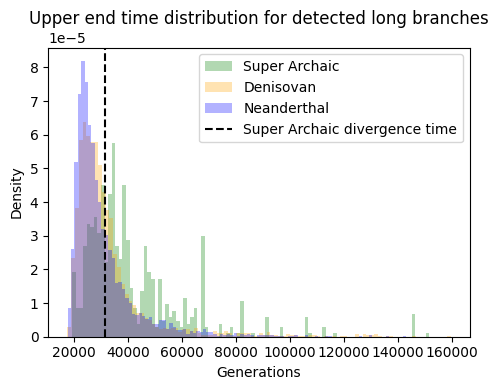

In [ ]:
idxs = range(30)

for idx in idxs:
    a = np.load(f"results/realdata/test_simulation/super_model/singer/n100_seed5_t15000_ind{idx}.chr1.xss.npz")
    if idx == 0:
        t2s = a['t2s']
        states = a['states']
    else:
        t2s = np.vstack((t2s, a['t2s']))
        states = np.vstack((states, a['states']))
treespan = a['treespan_phy'] / 1e6
truth_sup = Performance_utils().read_truth_bed("results/realdata/test_simulation/super_model/msprime/n100_seed5.SUPER.indiv.bed", 400)
truth_den = Performance_utils().read_truth_bed("results/realdata/test_simulation/super_model/msprime/n100_seed5.DEN.indiv.bed", 400)
truth_nea = Performance_utils().read_truth_bed("results/realdata/test_simulation/super_model/msprime/n100_seed5.NEA.indiv.bed", 400)

t2_sup = []
t2_den = []
t2_nea = []
t2_fdr = []
for idx in idxs:
    d_idx = []
    s_idx = []
    n_idx = []
    fdr_idx = []
    t_sup = truth_sup[idx]
    t_den = truth_den[idx]
    t_nea = truth_nea[idx]
    for i in range(states.shape[1]):
        if states[idx, i] > 0:
            seg = False
            [y1, y2] = treespan[i]
            for x in t_sup:
                [x1, x2] = x
                if (max(x1, y1) < min(x2, y2)):
                    s_idx.append(i)
                    seg = True
            if not seg:
                for x in t_den:
                    [x1, x2] = x
                    if (max(x1, y1) < min(x2, y2)):
                        d_idx.append(i)
                        seg = True
            if not seg:
                for x in t_nea:
                    [x1, x2] = x
                    if (max(x1, y1) < min(x2, y2)):
                        n_idx.append(i)
                        seg = True
            if not seg:
                fdr_idx.append(i)
    t2_sup = t2_sup + [t2s[idx, i] for i in s_idx]
    t2_den = t2_den + [t2s[idx, i] for i in d_idx]
    t2_fdr = t2_fdr + [t2s[idx, i] for i in fdr_idx]
    t2_nea = t2_nea + [t2s[idx, i] for i in n_idx]

fig, ax = plt.subplots(1,1,figsize=(5,4))

ax.hist(t2_sup, bins=100, alpha=0.3, color='green', label='Super Archaic', density=True)
ax.hist(t2_den, bins=100, alpha=0.3, color='orange', label='Denisovan', density=True)
ax.hist(t2_nea, bins=100, alpha=0.3, color='blue', label='Neanderthal', density=True)
ax.axvline(x=31500, color='black', linestyle='--', label='Super Archaic divergence time')
ax.set_xlabel('Generations')
ax.set_ylabel('Density')
ax.legend()
ax.set_title('Upper end time distribution for detected long branches')
plt.tight_layout()
plt.savefig('images/figS8_7a.pdf', bbox_inches='tight')


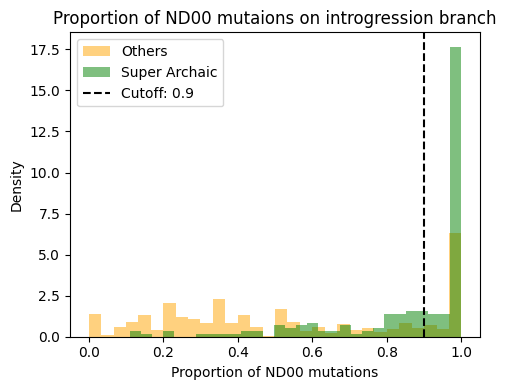

In [18]:
df = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t31500_den.count_merge.txt', sep = '\t')
df = df.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')
dff_den = df[(~df["truth_start"].str.contains('SUPER', case=True, na=False))]
dff_sup = df[(df['truth_assign'].str.contains('SUPER', case=True, na=False))]

fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.hist(dff_den["nd00_prop"], bins=30, alpha=0.5, color='orange', label='Others', density=True);
ax.hist(dff_sup["nd00_prop"], bins=30, alpha=0.5, color='green', label='Super Archaic', density=True);
ax.axvline(x=0.9, color='black', linestyle='--', label='Cutoff: 0.9');
ax.set_title('Proportion of ND00 mutaions on introgression branch');
ax.set_xlabel('Proportion of ND00 mutations');
ax.set_ylabel('Density');
ax.legend();
plt.tight_layout()
plt.savefig('images/figS6_7b.pdf', bbox_inches='tight')

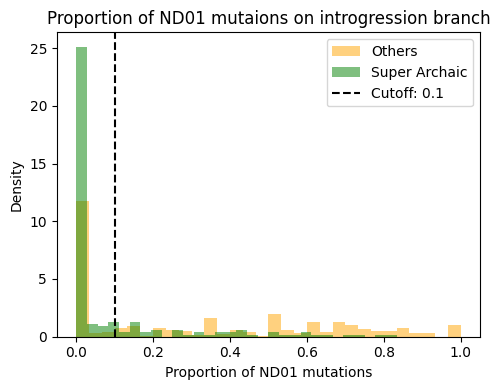

In [19]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.hist(dff_den["nd01_prop"], bins=30, alpha=0.5, color='orange', label='Others', density=True);
ax.hist(dff_sup["nd01_prop"], bins=30, alpha=0.5, color='green', label='Super Archaic', density=True);
ax.axvline(x=0.1, color='black', linestyle='--', label='Cutoff: 0.1');
ax.set_title('Proportion of ND01 mutaions on introgression branch');
ax.set_xlabel('Proportion of ND01 mutations');
ax.set_ylabel('Density');
ax.legend();
plt.tight_layout()
plt.savefig('images/figS6_7c.pdf', bbox_inches='tight')

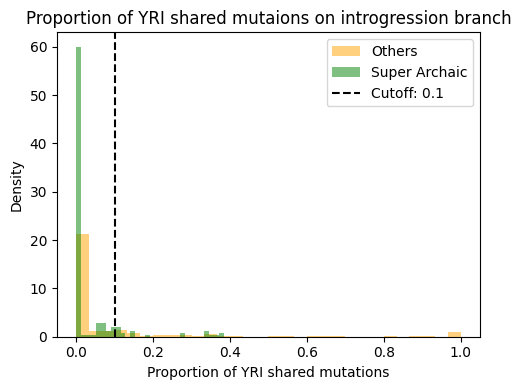

In [20]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.hist(dff_den["nYRI"], bins=30, alpha=0.5, color='orange', label='Others', density=True);
ax.hist(dff_sup["nYRI"], bins=30, alpha=0.5, color='green', label='Super Archaic', density=True);
ax.axvline(x=0.1, color='black', linestyle='--', label='Cutoff: 0.1');
ax.set_title('Proportion of YRI shared mutaions on introgression branch');
ax.set_xlabel('Proportion of YRI shared mutations');
ax.set_ylabel('Density');
ax.legend();
plt.tight_layout()
plt.savefig('images/figS6_7d.pdf', bbox_inches='tight')

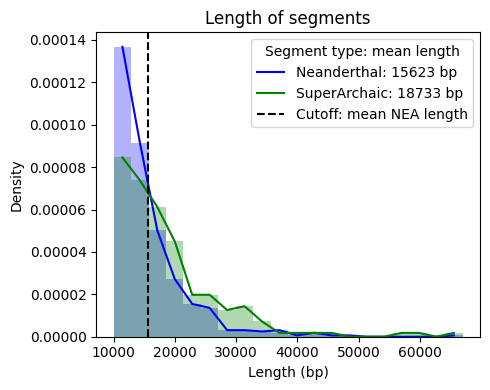

In [21]:
dff_nea = pd.read_csv('results/realdata/test_simulation/super_model/arghmm/singerave_t31500_nea.count_merge.txt', sep = '\t')
dff_nea = dff_nea.drop_duplicates(subset=['chromosome', 'start', 'end'], keep='first')

fig, ax = plt.subplots(1,1,figsize=(5,4))
counts, bin_edges = np.histogram(dff_nea["length(bp)"], bins=20, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.hist(dff_nea["length(bp)"], bins=20, alpha=0.3, color='blue', density=True);
ax.plot(bin_centers, counts, color='blue', label=f'Neanderthal: {dff_nea["length(bp)"].mean():.0f} bp')
counts, bin_edges = np.histogram(dff_sup["length(bp)"], bins=20, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.hist(dff_sup["length(bp)"], bins=20, alpha=0.3, color='green', density=True);
ax.plot(bin_centers, counts, color='green', label=f'SuperArchaic: {dff_sup["length(bp)"].mean():.0f} bp')
ax.axvline(x=dff_nea["length(bp)"].mean(), color='black', linestyle='--', label='Cutoff: mean NEA length');
ax.set_title('Length of segments');
ax.set_xlabel('Length (bp)');
ax.set_ylabel('Density');
ax.legend(title='Segment type: mean length');
plt.tight_layout()
plt.savefig('images/figS6_7e.pdf', bbox_inches='tight')

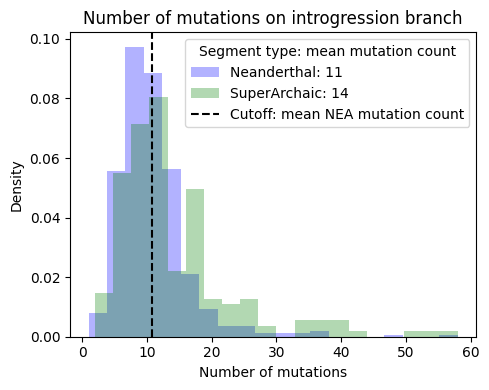

In [22]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.hist(dff_nea["tot_b"], bins=20, alpha=0.3, color='blue', density=True, label=f'Neanderthal: {dff_nea["tot_b"].mean():.0f}');
ax.hist(dff_sup["tot_b"], bins=20, alpha=0.3, color='green', density=True, label=f'SuperArchaic: {dff_sup["tot_b"].mean():.0f}');
ax.axvline(x=dff_nea["tot_b"].mean(), color='black', linestyle='--', label='Cutoff: mean NEA mutation count');
ax.set_title('Number of mutations on introgression branch');
ax.set_xlabel('Number of mutations');
ax.set_ylabel('Density');
ax.legend(title='Segment type: mean mutation count');
plt.tight_layout()
plt.savefig('images/figS6_7f.pdf', bbox_inches='tight')

# Upper-end time

In [13]:
def jackk(archaic, data):
    out = []
    dt = data[data["assign_label"]==archaic]
    for j in dt.index:
        nleaves = dt.loc[j, "n_leaves"].split(",")
        t2s = dt.loc[j, "t2s"].split(",")
        t1s = dt.loc[j, "t1s"].split(",")
        for k in range(len(nleaves)):
            if 0 < float(nleaves[k]) < 2:
                out.append(float(t2s[k]))
    overall_mean = np.mean(out)
    out = []
    for i in range(1, 11):
        sub = []
        dti = dt[dt["chromosome"] != i]
        for j in dti.index:
            nleaves = dti.loc[j, "n_leaves"].split(",")
            t2s = dti.loc[j, "t2s"].split(",")
            for k in range(len(nleaves)):
                if 0 < float(nleaves[k]) < 2:
                    sub.append(float(t2s[k]))
        out.append(np.mean(sub))
    weights = [1] * 10
    replication_factor = 100
    replicated_out = []
    for i, (theta, weight) in enumerate(zip(out, weights)):
        # Replicate each value proportionally to its weight
        n_replicates = int(weight * replication_factor)
        replicated_out = replicated_out + [theta] * n_replicates
    return overall_mean, replicated_out

data = pd.read_csv("results/realdata/test_simulation/eur_ghost_model/arghmm/singerave_t15000_gbr.count_merge.txt", sep='\t')
data = data[(data['nderived'] >= 30) & (data[["ND00", "ND10", "ND01", "ND11"]].sum(axis=1) >= 10)]
mean_nea, jackk_nea = jackk("Ghost", data)
print(mean_nea, np.percentile(jackk_nea, 2.5), np.percentile(jackk_nea, 97.5))

55145.829570501526 51085.13564465333 59196.538948863876


In [ ]:
def jackk(archaic, data):
    out = []
    dt = data[data["assign_label"]==archaic]
    for j in dt.index:
        sub = []
        nleaves = dt.loc[j, "n_leaves"].split(",")
        t2s = dt.loc[j, "t2s"].split(",")
        for k in range(len(nleaves)):
            sub.append(float(t2s[k]))
        out.append(np.median(sub))
    overall_mean = np.mean(out)
    out = []
    for i in range(1, 11):
        sub = []
        dti = dt[dt["chromosome"] != i]
        for j in dti.index:
            ssub = []
            nleaves = dti.loc[j, "n_leaves"].split(",")
            t2s = dti.loc[j, "t2s"].split(",")
            for k in range(len(nleaves)):
                ssub.append(float(t2s[k]))
            sub.append(np.median(ssub))
        out.append(np.mean(sub))
    weights = [1] * 10
    replication_factor = 100
    replicated_out = []
    for i, (theta, weight) in enumerate(zip(out, weights)):
        # Replicate each value proportionally to its weight
        n_replicates = int(weight * replication_factor)
        replicated_out = replicated_out + [theta] * n_replicates
    return overall_mean, replicated_out

data = pd.read_csv("results/realdata/test_simulation/eur_ghost_model/arghmm/singerave_t15000_gbr.count_merge.txt", sep='\t')
data = data[(data['nderived'] >= 30) & (data[["ND00", "ND10", "ND01", "ND11"]].sum(axis=1) >= 10)]
mean_nea, jackk_nea = jackk("Ghost", data)
print(mean_nea, np.percentile(jackk_nea, 2.5), np.percentile(jackk_nea, 97.5))